### Experimental Setup

In [8]:
FEATURE_SELECTION_METHOD = "WOA"
DEEP_LEARNING_CATEGORY = "Attention"
MODEL_ARCHITECTURE = "DistilGPT2"
DATASET_NAME = "Opensnoop"

**Developed By:** eDySec Research Team   
**Plartform:** Ubuntu 

All experiments in this notebook were conducted using **Python 3.10** with the following libraries:

`pandas==1.5.3`,  
`scikit-learn==1.2.2`,  
`openpyxl`,  
`numpy==1.23.5`,  
`scipy==1.9.3`,  
`tensorflow==2.11.0`,  
`matplotlib==3.7.1`,  
`seaborn==0.12.2`,  
`joblib==1.3.2`,  
`shap==0.41.0`,  
`lime`,  
`flaml[automl]==2.5.0`,  
`notebook==6.5.6`,  
`pywinpty==2.0.10`  (Only for windows)  `threadpoolctl==3.1.0` (for Ubuntu)   
`terminado==0.17.1`,  
`transformers==4.49.0`.

#### Full Environment Setup: https://github.com/tanzirmehedi/eDySec

These versions were used to ensure **consistent and reproducible experimental results**.

### Import Necessary Packages

In [2]:
# ============================================================
# Standard Library
# ============================================================
import os
import gc
import sys
import time
import warnings

warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

# ============================================================
# Numerical and Data Processing
# ============================================================
import numpy as np
import pandas as pd
import scipy

# ============================================================
# Visualization
# ============================================================
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# Scikit-learn
# ============================================================
import sklearn
from scipy.sparse import csr_matrix, hstack
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    auc,
    classification_report,
    cohen_kappa_score,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# ============================================================
# TensorFlow / Keras
# ============================================================
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau,
)
from tensorflow.keras.layers import (
    BatchNormalization,
    Dense,
    Dropout,
    LSTM,
)
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer

# ============================================================
# Transformers
# ============================================================
import transformers
from transformers import (
    BertTokenizer,
    GPT2Tokenizer,
    TFBertModel,
    TFGPT2Model,
)

# ============================================================
# AutoML and Model Persistence
# ============================================================
#from flaml import AutoML
import joblib

### Version Checking

In [2]:
print("=" * 60)
print("Python Version")
print("=" * 60)
print(sys.version)

print("\n" + "=" * 60)
print("Core Library Versions")
print("=" * 60)
print(f"NumPy            : {np.__version__}")
print(f"Pandas           : {pd.__version__}")
print(f"Matplotlib       : {matplotlib.__version__}")
print(f"Seaborn          : {sns.__version__}")
print(f"SciPy            : {scipy.__version__}")
print(f"Scikit-learn     : {sklearn.__version__}")
print(f"TensorFlow       : {tf.__version__}")
print(f"Transformers     : {transformers.__version__}")
print(f"Joblib           : {joblib.__version__}")

print("\n" + "=" * 60)
print("Keras Version")
print("=" * 60)
print(f"Keras (tf.keras) : {tf.keras.__version__}")

print("\n" + "=" * 60)
print("CUDA / GPU Info")
print("=" * 60)
print(f"Built with CUDA  : {tf.test.is_built_with_cuda()}")
print(f"GPU Available    : {len(tf.config.list_physical_devices('GPU')) > 0}")
print(f"GPUs             : {tf.config.list_physical_devices('GPU')}")

Python Version
3.10.20 (main, Mar 11 2026, 17:46:40) [GCC 14.3.0]

Core Library Versions
NumPy            : 1.23.5
Pandas           : 1.5.3
Matplotlib       : 3.7.1
Seaborn          : 0.12.2
SciPy            : 1.9.3
Scikit-learn     : 1.2.2
TensorFlow       : 2.11.0
Transformers     : 4.38.2
Joblib           : 1.3.2

Keras Version
Keras (tf.keras) : 2.11.0

CUDA / GPU Info
Built with CUDA  : True
GPU Available    : True
GPUs             : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


### GPU Checking

In [3]:
# ============================================================
# GPU Status and Resource Monitoring
# ============================================================

# Display NVIDIA GPU information including driver version,
# CUDA version, memory usage, and active processes

!nvidia-smi

/bin/bash: /home/n11894571/miniconda3/envs/tf211gpu/lib/libtinfo.so.6: no version information available (required by /bin/bash)
Thu Mar 26 21:31:11 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 595.54                 Driver Version: 595.79         CUDA Version: 13.2     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX A6000               On  |   00000000:01:00.0  On |                  Off |
| 30%   39C    P8             13W /  300W |   48316MiB /  49140MiB |      3%      Default |
|           

### GPU Status Checking

In [5]:
# ============================================================
# Detailed System and GPU Diagnostics
# ============================================================

print("=" * 60)
print("TensorFlow Environment Diagnostics")
print("=" * 60)

print(f"Conda Prefix        : {os.environ.get('CONDA_PREFIX')}")
print(f"LD_LIBRARY_PATH     : {os.environ.get('LD_LIBRARY_PATH')}")
print(f"TensorFlow Version  : {tf.__version__}")
print(f"Built with CUDA     : {tf.test.is_built_with_cuda()}")

gpus = tf.config.list_physical_devices('GPU')
print(f"Number of GPUs      : {len(gpus)}")

for idx, gpu in enumerate(gpus):
    print(f"GPU {idx}            : {gpu}")

print("=" * 60)

TensorFlow Environment Diagnostics
Conda Prefix        : /home/n11894571/miniconda3/envs/tf211gpu
LD_LIBRARY_PATH     : /home/n11894571/miniconda3/envs/tf211gpu/lib:
TensorFlow Version  : 2.11.0
Built with CUDA     : True
Number of GPUs      : 1
GPU 0            : PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


### Allocate as Much GPU Memory as Needed

In [6]:
# ============================================================
# Advanced GPU Configuration and Diagnostics
# ============================================================

gpus = tf.config.list_physical_devices('GPU')

print("=" * 60)
print("GPU Configuration")
print("=" * 60)

if gpus:
    print(f"Number of GPUs detected: {len(gpus)}")
    
    try:
        for idx, gpu in enumerate(gpus):
            # Disable memory growth (allocate full GPU memory)
            tf.config.experimental.set_memory_growth(gpu, False)
            print(f"GPU {idx}: Memory growth disabled (full allocation mode)")
    
    except RuntimeError as e:
        print(f"RuntimeError: {e}")
else:
    print("No GPU detected. Using CPU.")

print("=" * 60)

GPU Configuration
Number of GPUs detected: 1
GPU 0: Memory growth disabled (full allocation mode)


### Load QUT-DV25 Dataset

In [3]:
# ============================================================
# Data Loading and Initial Inspection
# ============================================================

# Define the dataset file path
file_path = 'QUT-DV25_'+DATASET_NAME+'_Traces.csv'

# Load the dataset into a pandas DataFrame
data = pd.read_csv(file_path)

# Display the first few rows for initial inspection
data.head()

,Package_Name,Total_Paths,Total_Error,Total_ File_Descriptor,Python_Related_Keywords,Install_Package_Keywords,Root_DIR_Installation,Temporary_DIR_Installation,Home_DIR_Installation,User_Access,Sys_Access,Etc_DIR_Installation,Other_DIR_Installation,Level
0,10Cent10-999.0.4.tar.gz,8045,8045,29,1083,2305,0,71,792,411,1225,151,5395,1
1,10Cent11-999.0.4.tar.gz,4790,4790,12,1616,843,2,87,1118,721,1200,104,1558,1
2,11Cent-999.0.0.tar.gz,26159,26159,27,3299,4536,0,200,2485,1072,1236,450,20716,1
3,11Cent-999.0.1.tar.gz,11194,11194,28,1521,2558,2,97,1035,891,1211,265,7693,1
4,11Cent-999.0.2.tar.gz,13561,13561,35,2656,5265,501,17,1497,1719,1219,291,8317,1


### Clear Backend Session

In [4]:
# ============================================================
# Memory Management and Session Reset
# ============================================================

# Trigger garbage collection to free unused memory
gc.collect()

# Clear the current TensorFlow/Keras session to release GPU/CPU resources
# This is particularly important when training multiple models sequentially
tf.keras.backend.clear_session()

### Selected Features

In [9]:
selected_features = ['Total_Paths', 'Total_ File_Descriptor', 'Python_Related_Keywords', 'Root_DIR_Installation', 'Temporary_DIR_Installation', 'User_Access', 'Sys_Access', 'Other_DIR_Installation']


### Data Preprocessing

In [10]:
# ============================================================
# Feature Selection and Dataset Preparation
# ============================================================

# Select the predefined feature subset
selected_features_with_target = selected_features.copy()

# Create a feature matrix from the selected features
X = data[selected_features_with_target].copy()

# Define the target variable
y = data['Level']

# ============================================================
# Train–Validation–Test Split (70%–15%–15%)
# ============================================================

# Step 1: Split into training (70%) and temporary set (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Step 2: Split temporary set into validation (15%) and test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

# ============================================================
# Dataset Summary
# ============================================================

print(f"Training set shape     : {X_train.shape}")
print(f"Validation set shape   : {X_val.shape}")
print(f"Test set shape         : {X_test.shape}")

Training set shape     : (9989, 8)
Validation set shape   : (2141, 8)
Test set shape         : (2141, 8)


### Setup OUTPUT_DIR

In [11]:
OUTPUT_DIR = "Evaluation_Outputs_"+DATASET_NAME+"_"+FEATURE_SELECTION_METHOD+"_"+DEEP_LEARNING_CATEGORY+"_"+MODEL_ARCHITECTURE
os.makedirs(OUTPUT_DIR, exist_ok=True)
OUTPUT_DIR

'Evaluation_Outputs_Opensnoop_WOA_Attention_DistilGPT2'

### Model

In [13]:
# ============================================================
# Define model saving configuration
# ============================================================

SAVE_DIR = OUTPUT_DIR
MODEL_NAME = os.path.join(SAVE_DIR, OUTPUT_DIR + ".h5")


# =========================================================
# Detect categorical and numeric columns
# =========================================================

categorical_cols = X_train.select_dtypes(include=['object']).columns
numeric_cols = X_train.select_dtypes(include=[np.number]).columns


# =========================================================
# Convert each row into a single text string
# =========================================================

def row_to_text(row):

    text = " ".join([f"{col}:{row[col]}" for col in categorical_cols])
    
    return text

X_train_text = X_train.apply(row_to_text, axis=1)
X_val_text   = X_val.apply(row_to_text, axis=1)
X_test_text  = X_test.apply(row_to_text, axis=1)


# =========================================================
# Load DistilGPT2 tokenizer and model
# =========================================================

MODEL = "distilgpt2"
tokenizer = GPT2Tokenizer.from_pretrained(MODEL)
tokenizer.pad_token = tokenizer.eos_token
gpt_model = TFGPT2Model.from_pretrained(MODEL)


# =========================================================
# Tokenization
# =========================================================

MAX_LEN = 64

def encode_texts(texts):

    enc = tokenizer(
        list(texts),
        padding="max_length",
        truncation=True,
        max_length=MAX_LEN,
        return_tensors="tf"
    )

    return enc

train_enc = encode_texts(X_train_text)
val_enc   = encode_texts(X_val_text)
test_enc  = encode_texts(X_test_text)


# =========================================================
# Process numeric features
# =========================================================

if len(numeric_cols) > 0:

    scaler = StandardScaler()

    X_train_num = scaler.fit_transform(X_train[numeric_cols])
    X_val_num   = scaler.transform(X_val[numeric_cols])
    X_test_num  = scaler.transform(X_test[numeric_cols])

else:

    X_train_num = np.empty((len(X_train), 0))
    X_val_num   = np.empty((len(X_val), 0))
    X_test_num  = np.empty((len(X_test), 0))

# Convert to float32
X_train_num = X_train_num.astype(np.float32)
X_val_num   = X_val_num.astype(np.float32)
X_test_num  = X_test_num.astype(np.float32)


# =========================================================
# Labels
# =========================================================

y_train = y_train.astype(np.float32)
y_val   = y_val.astype(np.float32)
y_test  = y_test.astype(np.float32)


# =========================================================
# Callbacks
# =========================================================

checkpoint_cb = ModelCheckpoint(
    MODEL_NAME,
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

reduce_lr_cb = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=200,
    verbose=1
)

early_stop_cb = EarlyStopping(
    monitor="val_loss",
    patience=200,
    restore_best_weights=True
)


# =========================================================
# Build DistilGPT2 Hybrid Model
# =========================================================

input_ids = tf.keras.Input(shape=(MAX_LEN,), dtype=tf.int32)
attention_mask = tf.keras.Input(shape=(MAX_LEN,), dtype=tf.int32)

# Transformer output
gpt_outputs = gpt_model(
    input_ids,
    attention_mask=attention_mask
)

# Use last token representation
text_features = gpt_outputs.last_hidden_state[:, -1, :]

# Numeric input
num_input = tf.keras.Input(shape=(X_train_num.shape[1],))
num_branch = layers.Dense(64, activation="relu")(num_input)
num_branch = layers.Dropout(0.2)(num_branch)

# Combine text + numeric
x = layers.Concatenate()([text_features, num_branch])

# Classification head
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dense(64, activation="relu")(x)

output = layers.Dense(1, activation="sigmoid")(x)

model = models.Model(
    inputs=[input_ids, attention_mask, num_input],
    outputs=output
)

model.compile(
    optimizer=tf.keras.optimizers.legacy.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

All model checkpoint layers were used when initializing TFGPT2Model.

All the layers of TFGPT2Model were initialized from the model checkpoint at distilgpt2.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFGPT2Model for predictions without further training.


Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_4 (InputLayer)           [(None, 64)]         0           []                               
                                                                                                  
 input_5 (InputLayer)           [(None, 64)]         0           []                               
                                                                                                  
 input_6 (InputLayer)           [(None, 8)]          0           []                               
                                                                                                  
 tfgpt2_model_1 (TFGPT2Model)   TFBaseModelOutputWi  81912576    ['input_4[0][0]',                
                                thPastAndCrossAtten               'input_5[0][0]']          

### Compime the Model

In [14]:
# ==========================
# Train model
# ==========================

start_train = time.time()

history = model.fit(

    [
        train_enc["input_ids"],
        train_enc["attention_mask"],
        X_train_num
    ],

    y_train,

    validation_data=(

        [
            val_enc["input_ids"],
            val_enc["attention_mask"],
            X_val_num
        ],

        y_val
    ),

    epochs=200,
    batch_size=16,

    callbacks=[
        checkpoint_cb,
        reduce_lr_cb,
        early_stop_cb
    ]

)

end_train = time.time()
training_time = end_train - start_train

Epoch 1/200
625/625 [==============================] - ETA: 0s - loss: 0.6186 - accuracy: 0.6476
Epoch 1: val_accuracy improved from -inf to 0.73050, saving model to Evaluation_Outputs_Opensnoop_WOA_Attention_DistilGPT2\Evaluation_Outputs_Opensnoop_WOA_Attention_DistilGPT2.h5
625/625 [==============================] - 52s 70ms/step - loss: 0.6186 - accuracy: 0.6476 - val_loss: 0.5198 - val_accuracy: 0.7305 - lr: 1.0000e-04
Epoch 2/200
624/625 [============================>.] - ETA: 0s - loss: 0.5104 - accuracy: 0.7439
Epoch 2: val_accuracy improved from 0.73050 to 0.77767, saving model to Evaluation_Outputs_Opensnoop_WOA_Attention_DistilGPT2\Evaluation_Outputs_Opensnoop_WOA_Attention_DistilGPT2.h5
625/625 [==============================] - 38s 61ms/step - loss: 0.5105 - accuracy: 0.7437 - val_loss: 0.4568 - val_accuracy: 0.7777 - lr: 1.0000e-04
Epoch 3/200
625/625 [==============================] - ETA: 0s - loss: 0.4614 - accuracy: 0.7831
Epoch 3: val_accuracy improved from 0.77767 to

625/625 [==============================] - 31s 50ms/step - loss: 0.3392 - accuracy: 0.8414 - val_loss: 0.3053 - val_accuracy: 0.8636 - lr: 1.0000e-04
Epoch 25/200
625/625 [==============================] - ETA: 0s - loss: 0.3343 - accuracy: 0.8449
Epoch 25: val_accuracy did not improve from 0.86455
625/625 [==============================] - 31s 49ms/step - loss: 0.3343 - accuracy: 0.8449 - val_loss: 0.3069 - val_accuracy: 0.8561 - lr: 1.0000e-04
Epoch 26/200
625/625 [==============================] - ETA: 0s - loss: 0.3383 - accuracy: 0.8439
Epoch 26: val_accuracy did not improve from 0.86455
625/625 [==============================] - 31s 49ms/step - loss: 0.3383 - accuracy: 0.8439 - val_loss: 0.3056 - val_accuracy: 0.8627 - lr: 1.0000e-04
Epoch 27/200
624/625 [============================>.] - ETA: 0s - loss: 0.3326 - accuracy: 0.8431
Epoch 27: val_accuracy did not improve from 0.86455
625/625 [==============================] - 31s 49ms/step - loss: 0.3325 - accuracy: 0.8432 - val_los

Epoch 50/200
625/625 [==============================] - ETA: 0s - loss: 0.3074 - accuracy: 0.8585
Epoch 50: val_accuracy improved from 0.87109 to 0.87436, saving model to Evaluation_Outputs_Opensnoop_WOA_Attention_DistilGPT2\Evaluation_Outputs_Opensnoop_WOA_Attention_DistilGPT2.h5
625/625 [==============================] - 34s 55ms/step - loss: 0.3074 - accuracy: 0.8585 - val_loss: 0.2890 - val_accuracy: 0.8744 - lr: 1.0000e-04
Epoch 51/200
624/625 [============================>.] - ETA: 0s - loss: 0.3073 - accuracy: 0.8595
Epoch 51: val_accuracy did not improve from 0.87436
625/625 [==============================] - 31s 49ms/step - loss: 0.3072 - accuracy: 0.8595 - val_loss: 0.2873 - val_accuracy: 0.8702 - lr: 1.0000e-04
Epoch 52/200
625/625 [==============================] - ETA: 0s - loss: 0.3056 - accuracy: 0.8623
Epoch 52: val_accuracy did not improve from 0.87436
625/625 [==============================] - 31s 49ms/step - loss: 0.3056 - accuracy: 0.8623 - val_loss: 0.2879 - val_ac

Epoch 76/200
625/625 [==============================] - ETA: 0s - loss: 0.2969 - accuracy: 0.8640
Epoch 76: val_accuracy did not improve from 0.87996
625/625 [==============================] - 31s 49ms/step - loss: 0.2969 - accuracy: 0.8640 - val_loss: 0.2774 - val_accuracy: 0.8762 - lr: 1.0000e-04
Epoch 77/200
624/625 [============================>.] - ETA: 0s - loss: 0.2904 - accuracy: 0.8715
Epoch 77: val_accuracy did not improve from 0.87996
625/625 [==============================] - 31s 49ms/step - loss: 0.2905 - accuracy: 0.8715 - val_loss: 0.2771 - val_accuracy: 0.8734 - lr: 1.0000e-04
Epoch 78/200
625/625 [==============================] - ETA: 0s - loss: 0.2926 - accuracy: 0.8692
Epoch 78: val_accuracy did not improve from 0.87996
625/625 [==============================] - 31s 49ms/step - loss: 0.2926 - accuracy: 0.8692 - val_loss: 0.2769 - val_accuracy: 0.8762 - lr: 1.0000e-04
Epoch 79/200
624/625 [============================>.] - ETA: 0s - loss: 0.2924 - accuracy: 0.8677
Ep

625/625 [==============================] - 31s 49ms/step - loss: 0.2798 - accuracy: 0.8751 - val_loss: 0.2708 - val_accuracy: 0.8772 - lr: 1.0000e-04
Epoch 103/200
625/625 [==============================] - ETA: 0s - loss: 0.2815 - accuracy: 0.8765
Epoch 103: val_accuracy improved from 0.88323 to 0.88370, saving model to Evaluation_Outputs_Opensnoop_WOA_Attention_DistilGPT2\Evaluation_Outputs_Opensnoop_WOA_Attention_DistilGPT2.h5
625/625 [==============================] - 35s 55ms/step - loss: 0.2815 - accuracy: 0.8765 - val_loss: 0.2704 - val_accuracy: 0.8837 - lr: 1.0000e-04
Epoch 104/200
625/625 [==============================] - ETA: 0s - loss: 0.2782 - accuracy: 0.8790
Epoch 104: val_accuracy improved from 0.88370 to 0.88417, saving model to Evaluation_Outputs_Opensnoop_WOA_Attention_DistilGPT2\Evaluation_Outputs_Opensnoop_WOA_Attention_DistilGPT2.h5
625/625 [==============================] - 35s 55ms/step - loss: 0.2782 - accuracy: 0.8790 - val_loss: 0.2699 - val_accuracy: 0.8842

625/625 [==============================] - 31s 49ms/step - loss: 0.2739 - accuracy: 0.8779 - val_loss: 0.2668 - val_accuracy: 0.8781 - lr: 1.0000e-04
Epoch 128/200
625/625 [==============================] - ETA: 0s - loss: 0.2735 - accuracy: 0.8808
Epoch 128: val_accuracy did not improve from 0.88977
625/625 [==============================] - 31s 49ms/step - loss: 0.2735 - accuracy: 0.8808 - val_loss: 0.2668 - val_accuracy: 0.8786 - lr: 1.0000e-04
Epoch 129/200
625/625 [==============================] - ETA: 0s - loss: 0.2694 - accuracy: 0.8818
Epoch 129: val_accuracy did not improve from 0.88977
625/625 [==============================] - 31s 49ms/step - loss: 0.2694 - accuracy: 0.8818 - val_loss: 0.2633 - val_accuracy: 0.8856 - lr: 1.0000e-04
Epoch 130/200
625/625 [==============================] - ETA: 0s - loss: 0.2734 - accuracy: 0.8793
Epoch 130: val_accuracy did not improve from 0.88977
625/625 [==============================] - 31s 49ms/step - loss: 0.2734 - accuracy: 0.8793 - v

Epoch 155/200
625/625 [==============================] - ETA: 0s - loss: 0.2624 - accuracy: 0.8820
Epoch 155: val_accuracy did not improve from 0.88977
625/625 [==============================] - 31s 49ms/step - loss: 0.2624 - accuracy: 0.8820 - val_loss: 0.2607 - val_accuracy: 0.8879 - lr: 1.0000e-04
Epoch 156/200
624/625 [============================>.] - ETA: 0s - loss: 0.2670 - accuracy: 0.8821
Epoch 156: val_accuracy did not improve from 0.88977
625/625 [==============================] - 31s 49ms/step - loss: 0.2670 - accuracy: 0.8821 - val_loss: 0.2585 - val_accuracy: 0.8870 - lr: 1.0000e-04
Epoch 157/200
624/625 [============================>.] - ETA: 0s - loss: 0.2645 - accuracy: 0.8821
Epoch 157: val_accuracy did not improve from 0.88977
625/625 [==============================] - 31s 49ms/step - loss: 0.2644 - accuracy: 0.8822 - val_loss: 0.2594 - val_accuracy: 0.8888 - lr: 1.0000e-04
Epoch 158/200
625/625 [==============================] - ETA: 0s - loss: 0.2654 - accuracy: 0.

625/625 [==============================] - ETA: 0s - loss: 0.2610 - accuracy: 0.8835
Epoch 181: val_accuracy did not improve from 0.89071
625/625 [==============================] - 31s 49ms/step - loss: 0.2610 - accuracy: 0.8835 - val_loss: 0.2593 - val_accuracy: 0.8860 - lr: 1.0000e-04
Epoch 182/200
625/625 [==============================] - ETA: 0s - loss: 0.2582 - accuracy: 0.8873
Epoch 182: val_accuracy did not improve from 0.89071
625/625 [==============================] - 31s 49ms/step - loss: 0.2582 - accuracy: 0.8873 - val_loss: 0.2604 - val_accuracy: 0.8832 - lr: 1.0000e-04
Epoch 183/200
624/625 [============================>.] - ETA: 0s - loss: 0.2602 - accuracy: 0.8856
Epoch 183: val_accuracy did not improve from 0.89071
625/625 [==============================] - 31s 49ms/step - loss: 0.2603 - accuracy: 0.8856 - val_loss: 0.2575 - val_accuracy: 0.8884 - lr: 1.0000e-04
Epoch 184/200
624/625 [============================>.] - ETA: 0s - loss: 0.2560 - accuracy: 0.8882
Epoch 184

### Clear Backend Session

In [15]:
# ============================================================
# Memory Management and Session Reset
# ============================================================

# Trigger garbage collection to free unused memory
gc.collect()

# Clear the current TensorFlow/Keras session to release GPU/CPU resources
# This is particularly important when training multiple models sequentially
tf.keras.backend.clear_session()

### Model Validation

In [16]:
# ==========================
# Validation Evaluation
# ==========================

start_val = time.time()

val_loss, val_acc = model.evaluate(
    [
        val_enc["input_ids"],
        val_enc["attention_mask"],
        X_val_num
    ],
    y_val,
    verbose=0
)

end_val = time.time()
validation_time = end_val - start_val


# ==========================
# Test Evaluation
# ==========================

start_test = time.time()

test_loss, test_acc = model.evaluate(
    [
        test_enc["input_ids"],
        test_enc["attention_mask"],
        X_test_num
    ],
    y_test,
    verbose=0
)

end_test = time.time()
testing_time = end_test - start_test


# ==========================
# Print Results
# ==========================

print(f"\nTraining Time: {training_time:.2f} seconds")
print(f"Validation Time: {validation_time:.2f} seconds")
print(f"Testing Time: {testing_time:.2f} seconds")

print(f"\nValidation Accuracy: {val_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")


Training Time: 6279.26 seconds
Validation Time: 1.62 seconds
Testing Time: 1.15 seconds

Validation Accuracy: 0.8842
Test Accuracy: 0.8823


### Save Training Log

In [17]:
# Convert history to DataFrame
df = pd.DataFrame(history.history)

# Add epoch column (starting from 1)
df.insert(0, "epoch", range(1, len(df) + 1))

# Optional: round values for cleaner output
df = df.round(6)

# Define save path
training_log_path = os.path.join(
    OUTPUT_DIR,
    "training_log.xlsx"
)

# Save file
df.to_excel(training_log_path, index=False)

# Confirmation
print(f"Training log saved at: {training_log_path}")

# Preview
df.head()

Training log saved at: Evaluation_Outputs_Opensnoop_WOA_Attention_DistilGPT2\training_log.xlsx


,epoch,loss,accuracy,val_loss,val_accuracy,lr
0,1,0.618566,0.647612,0.519835,0.730500,0.0001
1,2,0.510478,0.743718,0.456830,0.777674,0.0001
2,3,0.461411,0.783061,0.400593,0.826249,0.0001
3,4,0.432555,0.801281,0.384531,0.840262,0.0001
4,5,0.415897,0.809691,0.361944,0.845866,0.0001


### Trainig and Validation Plot

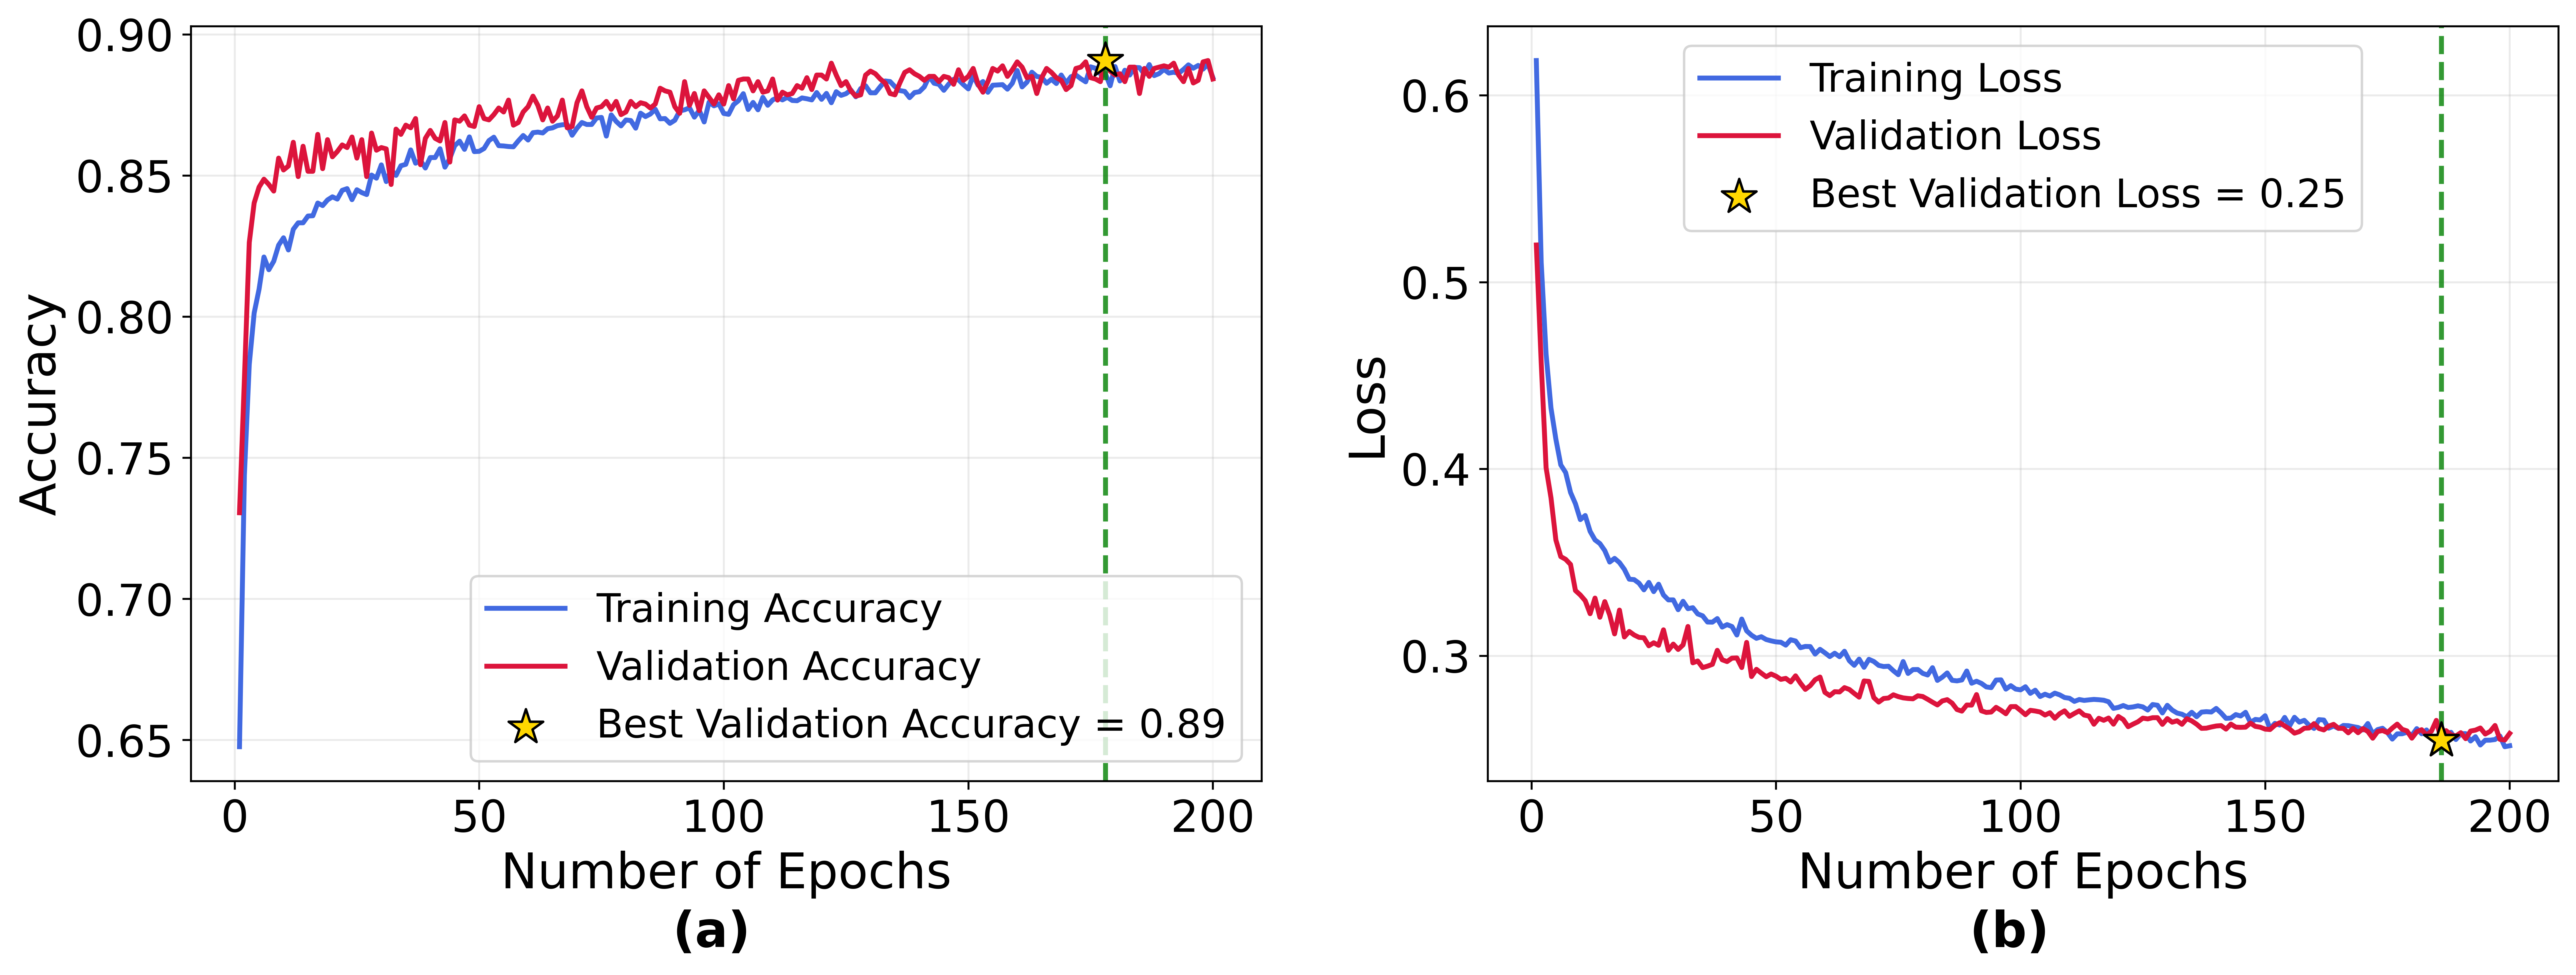

In [18]:
# ============================================================
# Font Settings
# ============================================================
plt.rcParams.update({
    "font.size": 20,
    "axes.titlesize": 20,
    "axes.labelsize": 20,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 16
})

# ============================================================
# Identify Best Epochs
# ============================================================

if "epoch" not in df.columns:
    df["epoch"] = range(1, len(df) + 1)

best_acc_idx = df["val_accuracy"].idxmax()
best_acc_epoch = int(df.loc[best_acc_idx, "epoch"])
best_acc = float(df.loc[best_acc_idx, "val_accuracy"])

best_loss_idx = df["val_loss"].idxmin()
best_loss_epoch = int(df.loc[best_loss_idx, "epoch"])
best_loss = float(df.loc[best_loss_idx, "val_loss"])

# ============================================================
# Combined Learning Curves
# ============================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), dpi=600)

# ============================================================
# Accuracy Plot
# ============================================================
ax1.plot(df["epoch"], df["accuracy"], linewidth=2,
         color="royalblue", label="Training Accuracy")

ax1.plot(df["epoch"], df["val_accuracy"], linewidth=2,
         color="crimson", label="Validation Accuracy")

ax1.axvline(best_acc_epoch,
            linestyle="--",
            linewidth=2,
            color="green",
            alpha=0.8)

ax1.scatter(best_acc_epoch, best_acc,
            s=220, marker="*", color="gold", edgecolor="black",
            zorder=3,
            label=f"Best Validation Accuracy = {best_acc:.2f}")

ax1.set_xlabel("Number of Epochs")
ax1.set_ylabel("Accuracy")
ax1.grid(True, alpha=0.25)
ax1.legend(frameon=True)

# Accuracy plot ticks
for tick, label in zip(ax1.get_xticks(), ax1.get_xticklabels()):
    if int(tick) == best_acc_epoch:
        label.set_fontweight("bold")
        label.set_color("green")
        
# ============================================================
# Loss Plot
# ============================================================
ax2.plot(df["epoch"], df["loss"], linewidth=2,
         color="royalblue", label="Training Loss")

ax2.plot(df["epoch"], df["val_loss"], linewidth=2,
         color="crimson", label="Validation Loss")

ax2.axvline(best_loss_epoch,
            linestyle="--",
            linewidth=2,
            color="green",
            alpha=0.8)

ax2.scatter(best_loss_epoch, best_loss,
            s=220, marker="*", color="gold", edgecolor="black",
            zorder=3,
            label=f"Best Validation Loss = {best_loss:.2f}")

ax2.set_xlabel("Number of Epochs")
ax2.set_ylabel("Loss")
ax2.grid(True, alpha=0.25)
ax2.legend(frameon=True)

# Loss plot ticks
for tick, label in zip(ax2.get_xticks(), ax2.get_xticklabels()):
    if int(tick) == best_loss_epoch:
        label.set_fontweight("bold")
        label.set_color("green")
        
# ============================================================
# Panel Labels
# ============================================================
ax1.text(0.45, -0.22, "(a)", transform=ax1.transAxes,
         fontsize=20, fontweight="bold")

ax2.text(0.45, -0.22, "(b)", transform=ax2.transAxes,
         fontsize=20, fontweight="bold")

# ============================================================
# Final layout
# ============================================================
fig.tight_layout()

fig.savefig(os.path.join(OUTPUT_DIR, "learning_curves.png"),
            dpi=600, bbox_inches="tight")

fig.savefig(os.path.join(OUTPUT_DIR, "learning_curves.pdf"),
            bbox_inches="tight")

plt.show()

### Classification Report


Evaluation Results: Train
Accuracy  : 0.900390
Precision : 0.935456
Recall    : 0.859892
F1-score  : 0.896084
ROC AUC   : 0.967598
----------------------------------------------------------------------
Classification Report:
              precision    recall  f1-score   support

         0.0   0.870627  0.940800  0.904355      5000
         1.0   0.935456  0.859892  0.896084      4989

    accuracy                       0.900390      9989
   macro avg   0.903042  0.900346  0.900219      9989
weighted avg   0.903006  0.900390  0.900224      9989



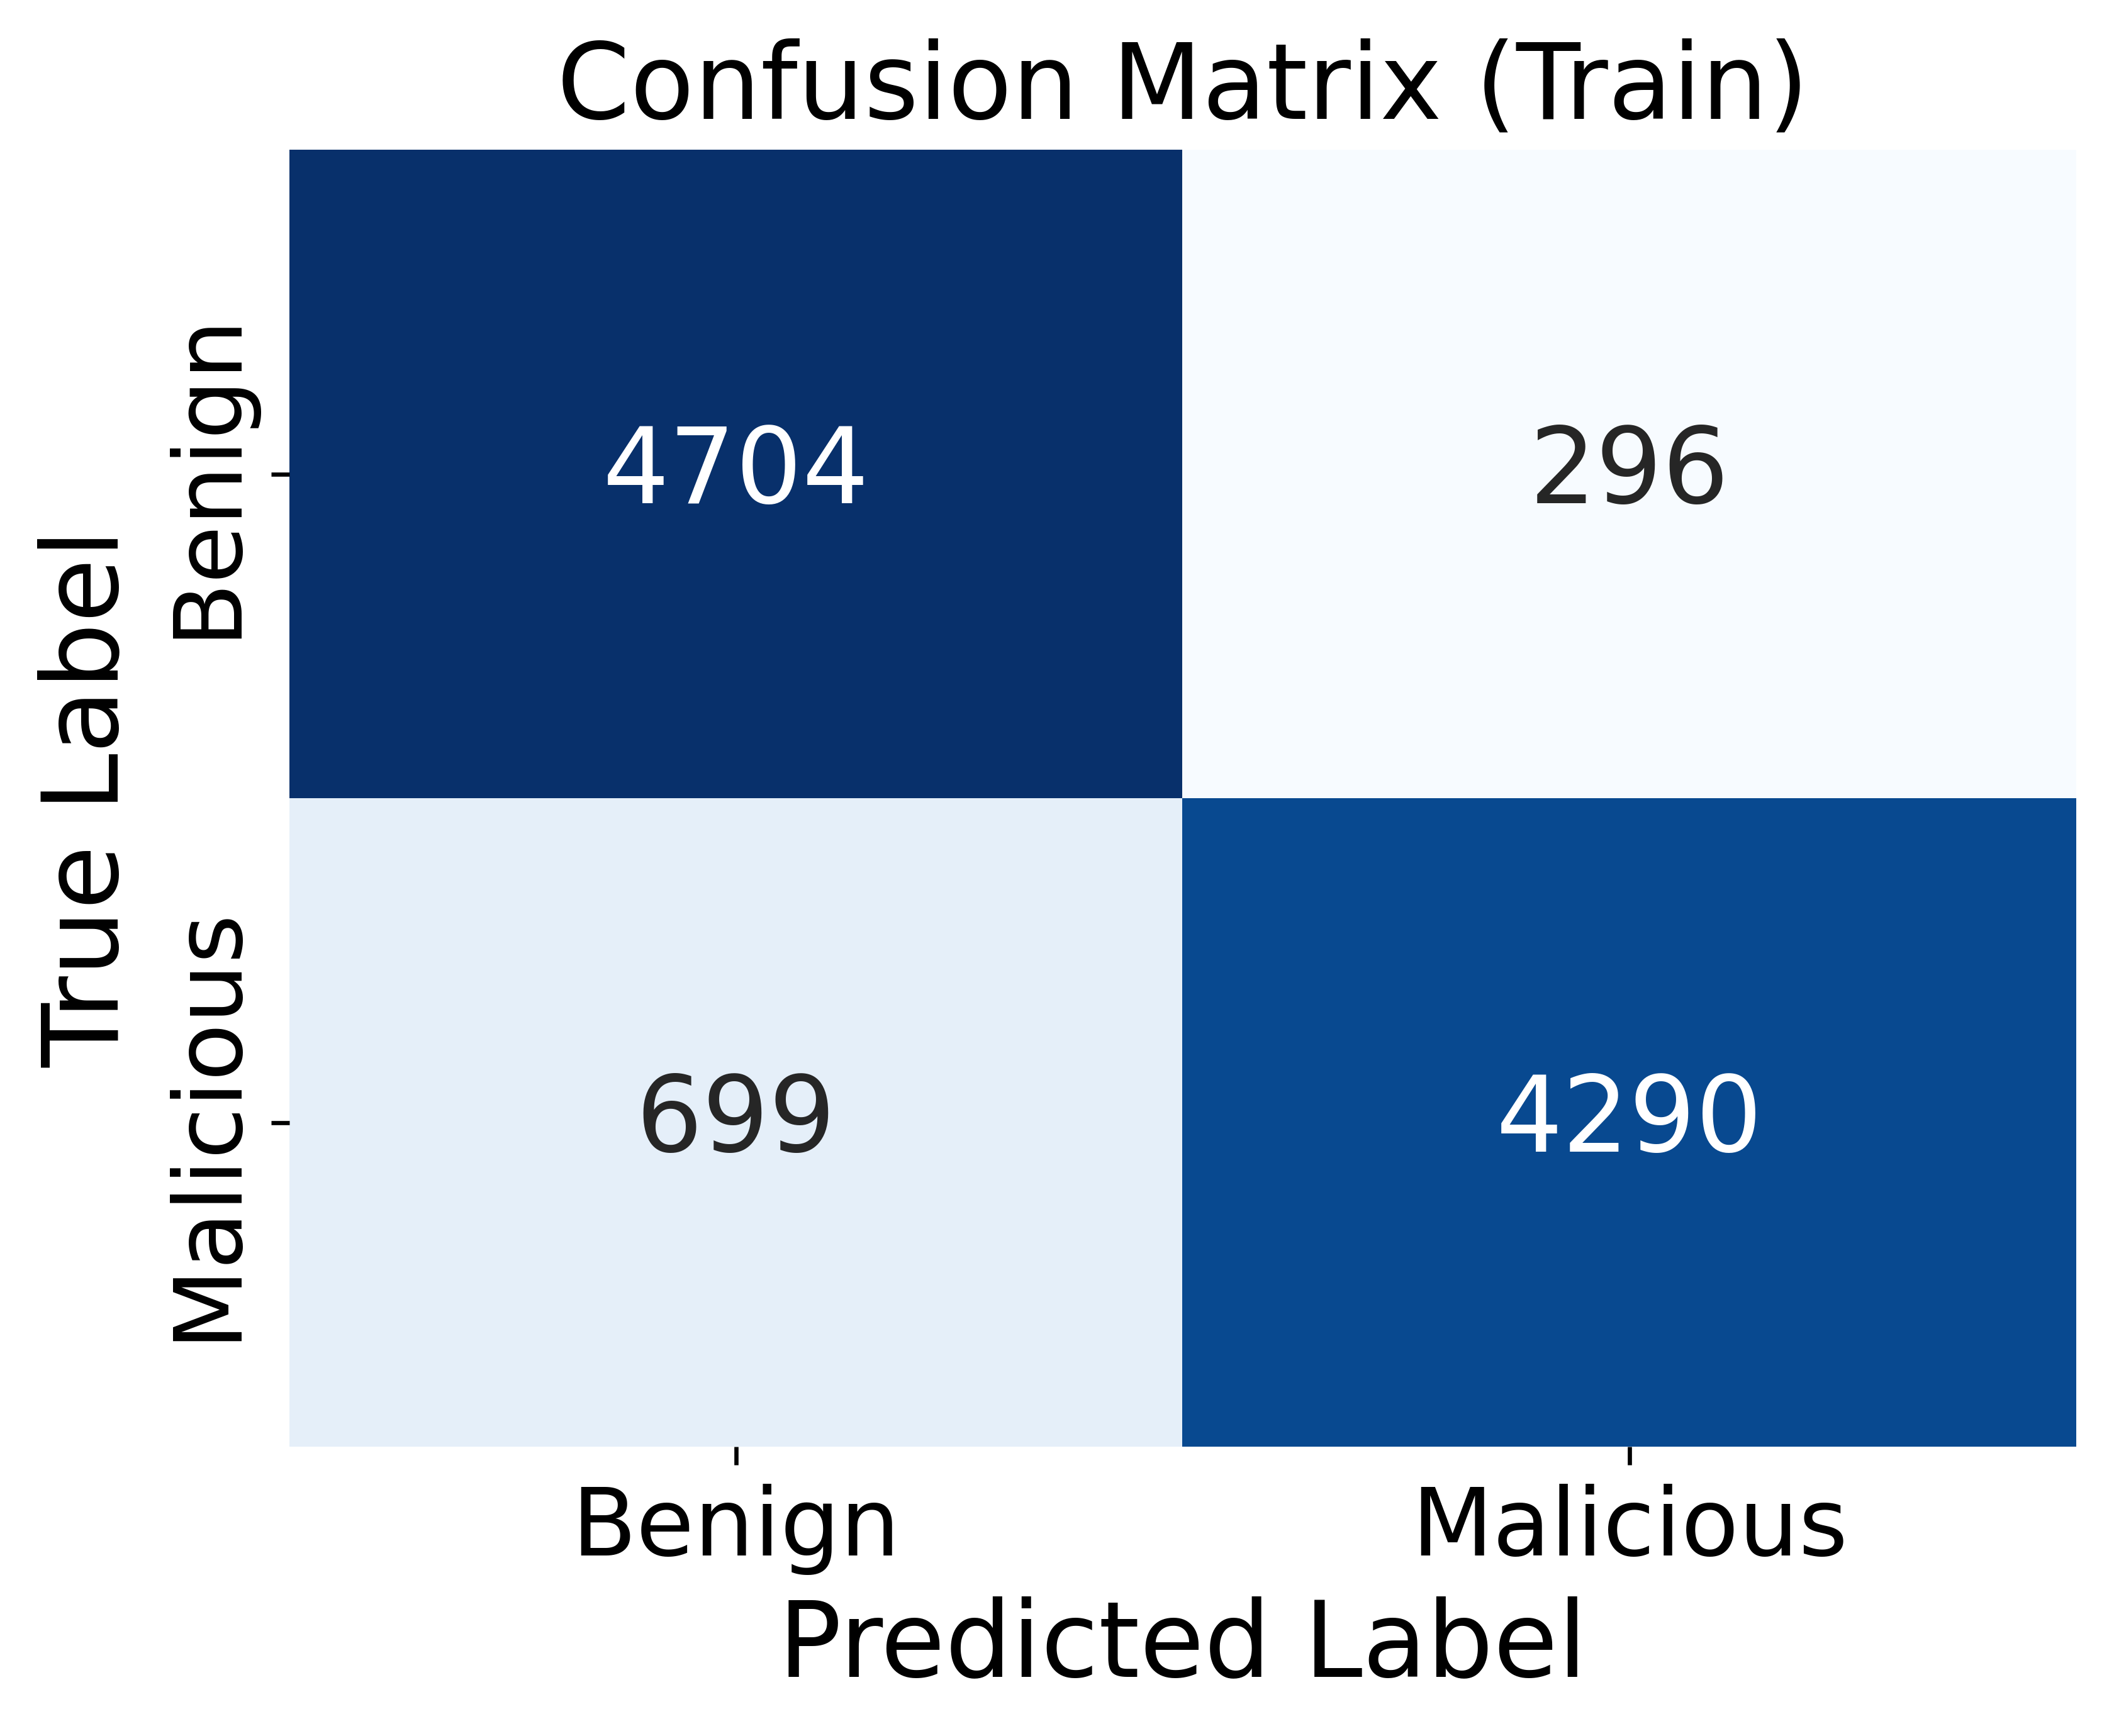

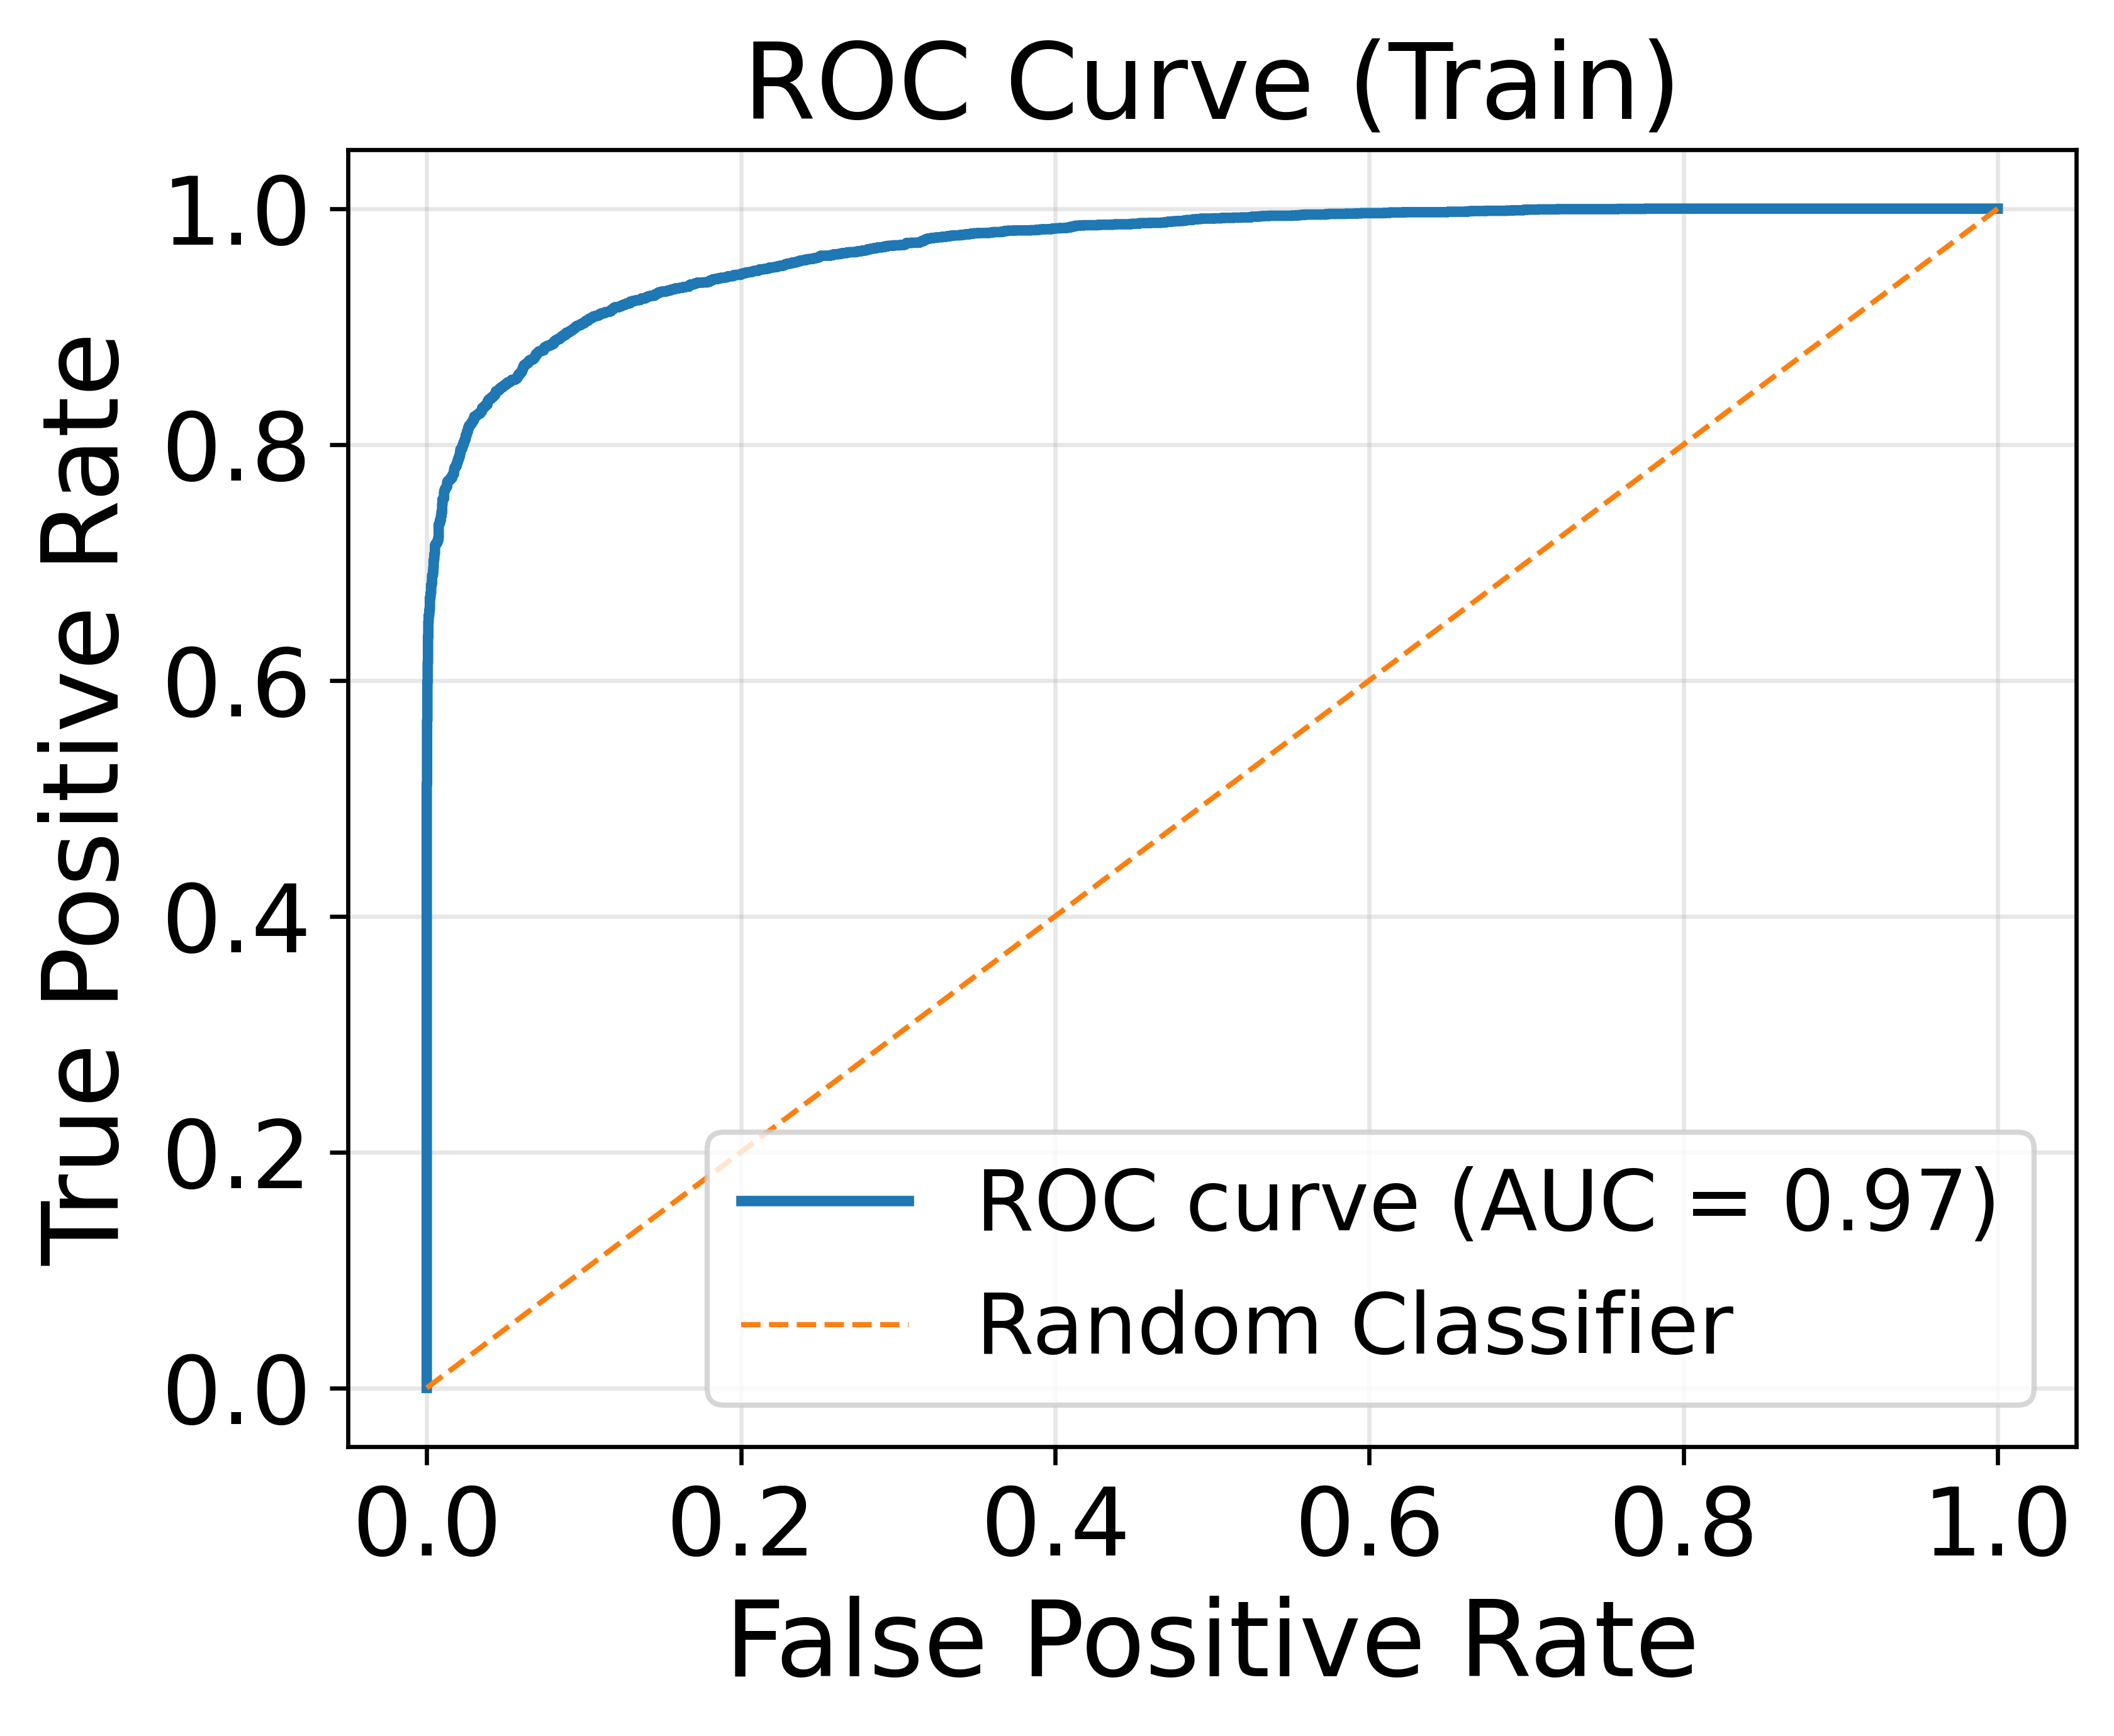


Evaluation Results: Validation
Accuracy  : 0.884166
Precision : 0.915066
Recall    : 0.846586
F1-score  : 0.879495
ROC AUC   : 0.958577
----------------------------------------------------------------------
Classification Report:
              precision    recall  f1-score   support

         0.0   0.857639  0.921642  0.888489      1072
         1.0   0.915066  0.846586  0.879495      1069

    accuracy                       0.884166      2141
   macro avg   0.886352  0.884114  0.883992      2141
weighted avg   0.886312  0.884166  0.883998      2141



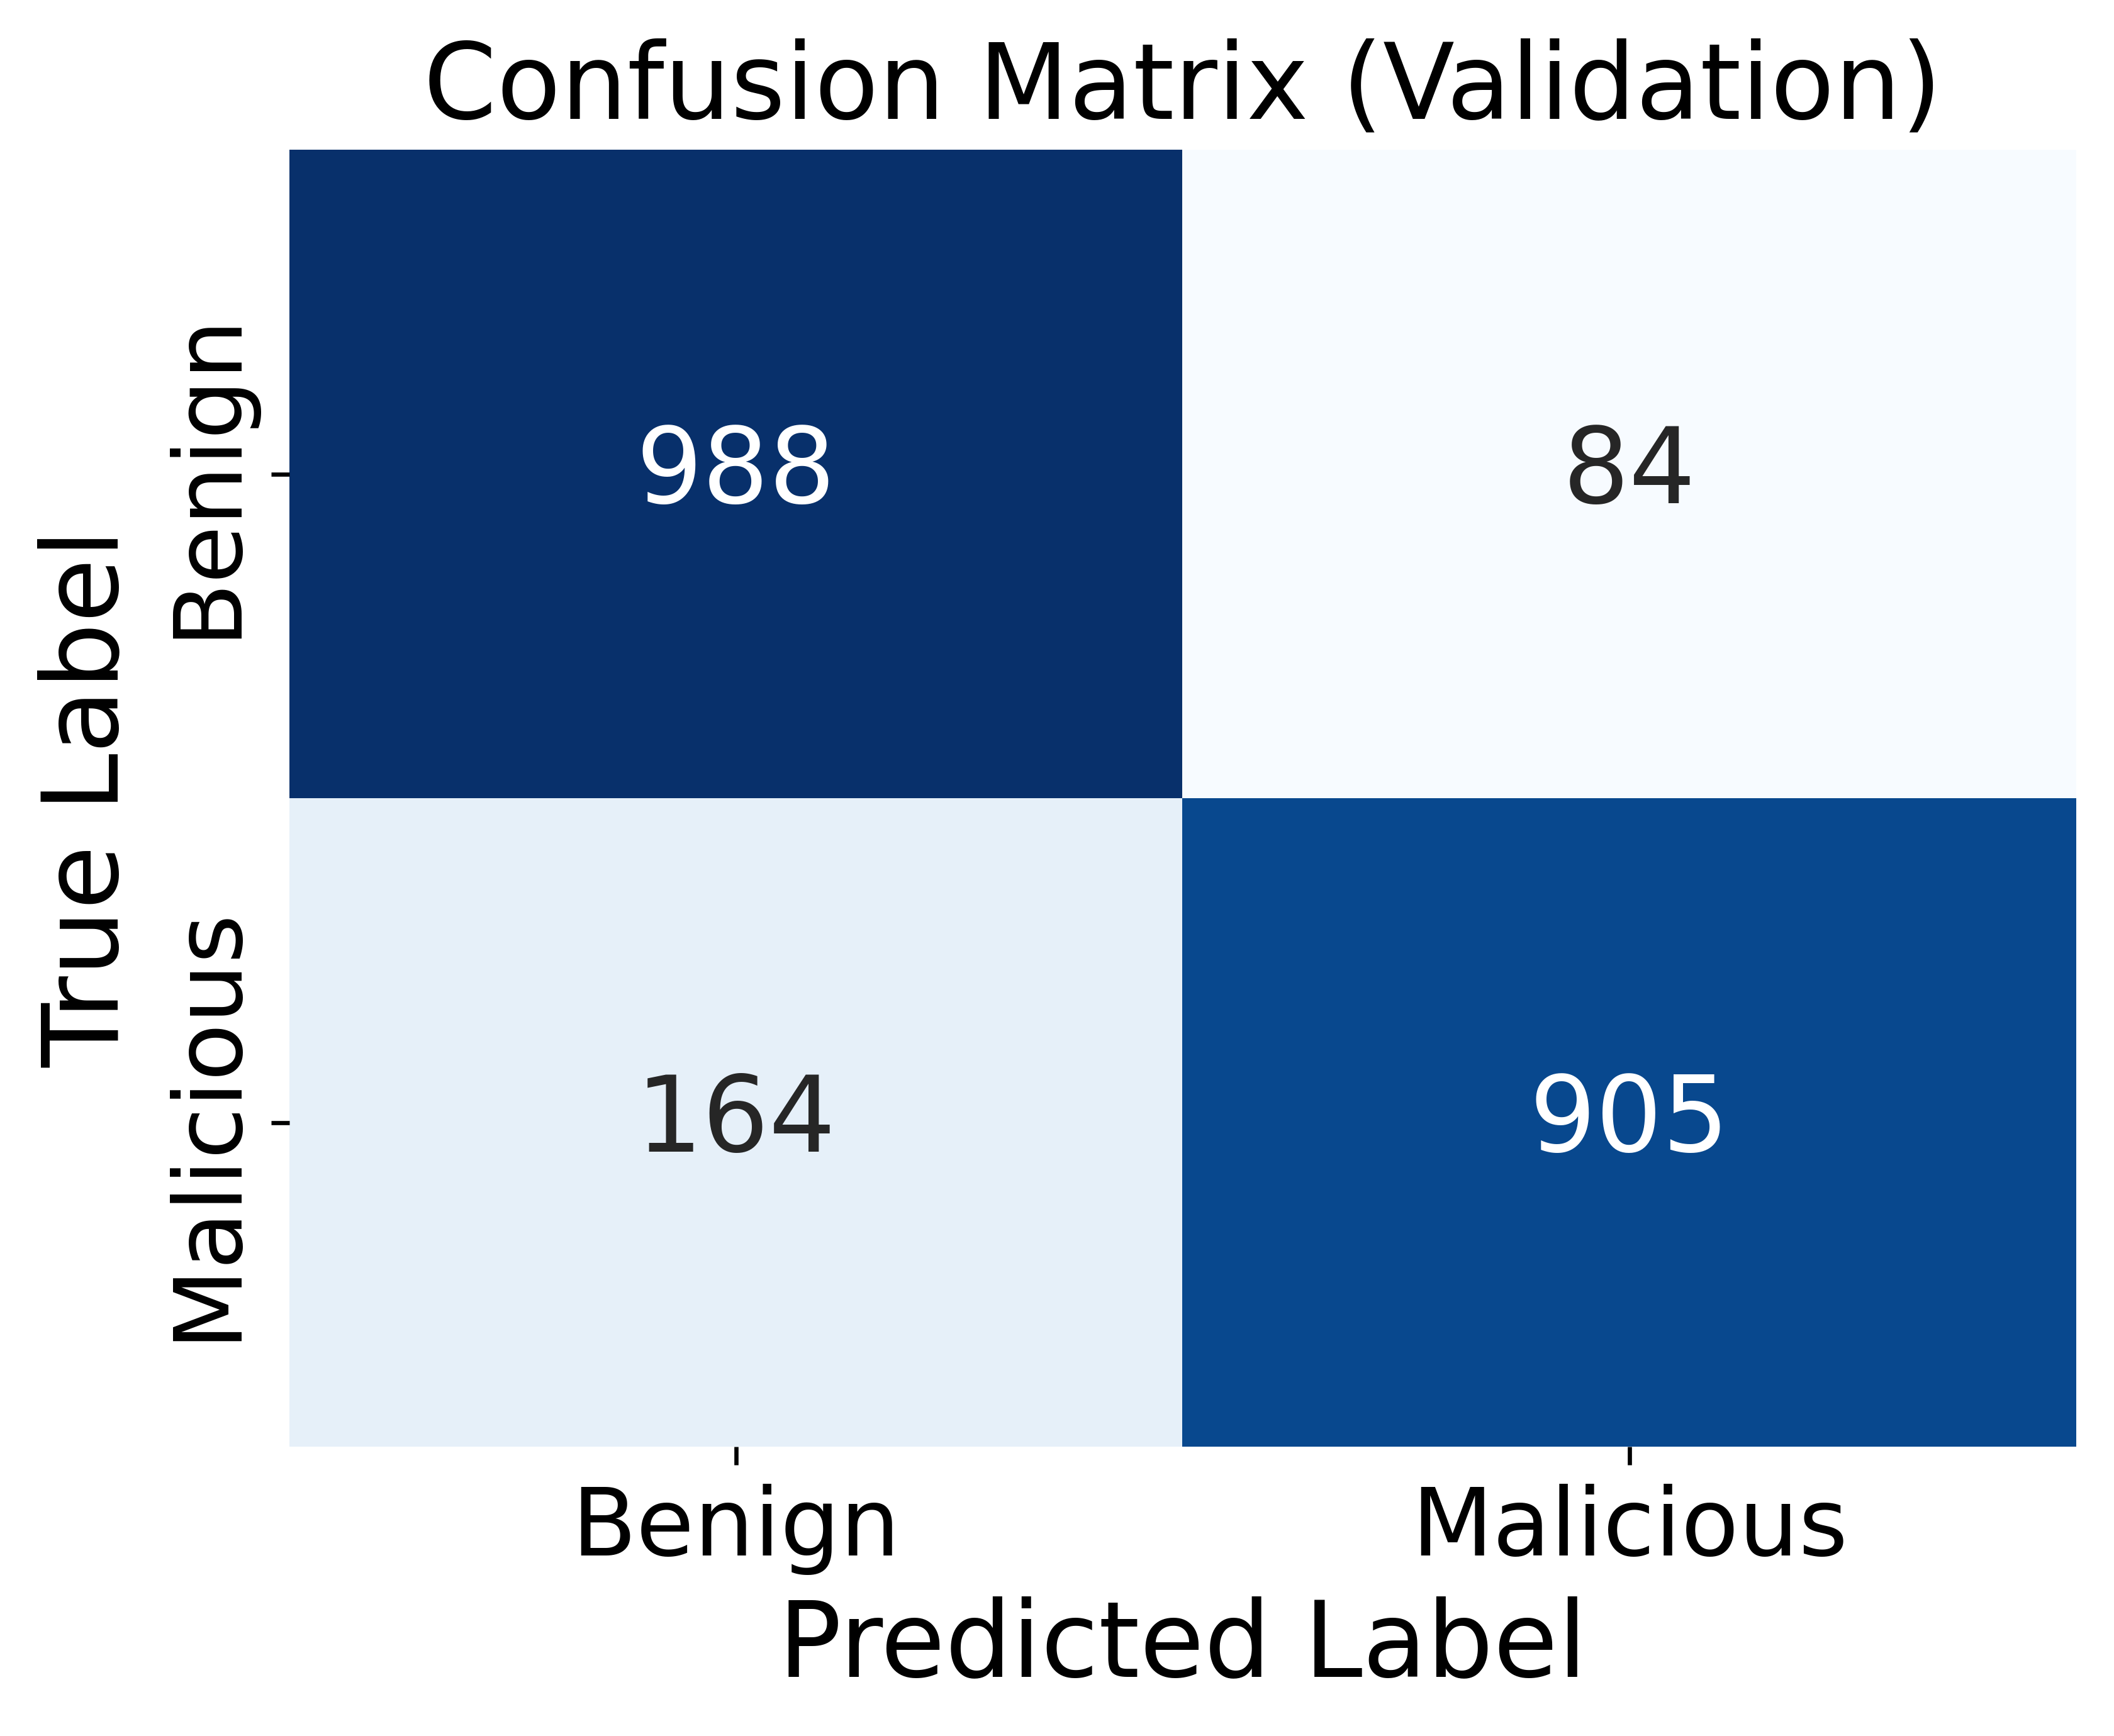

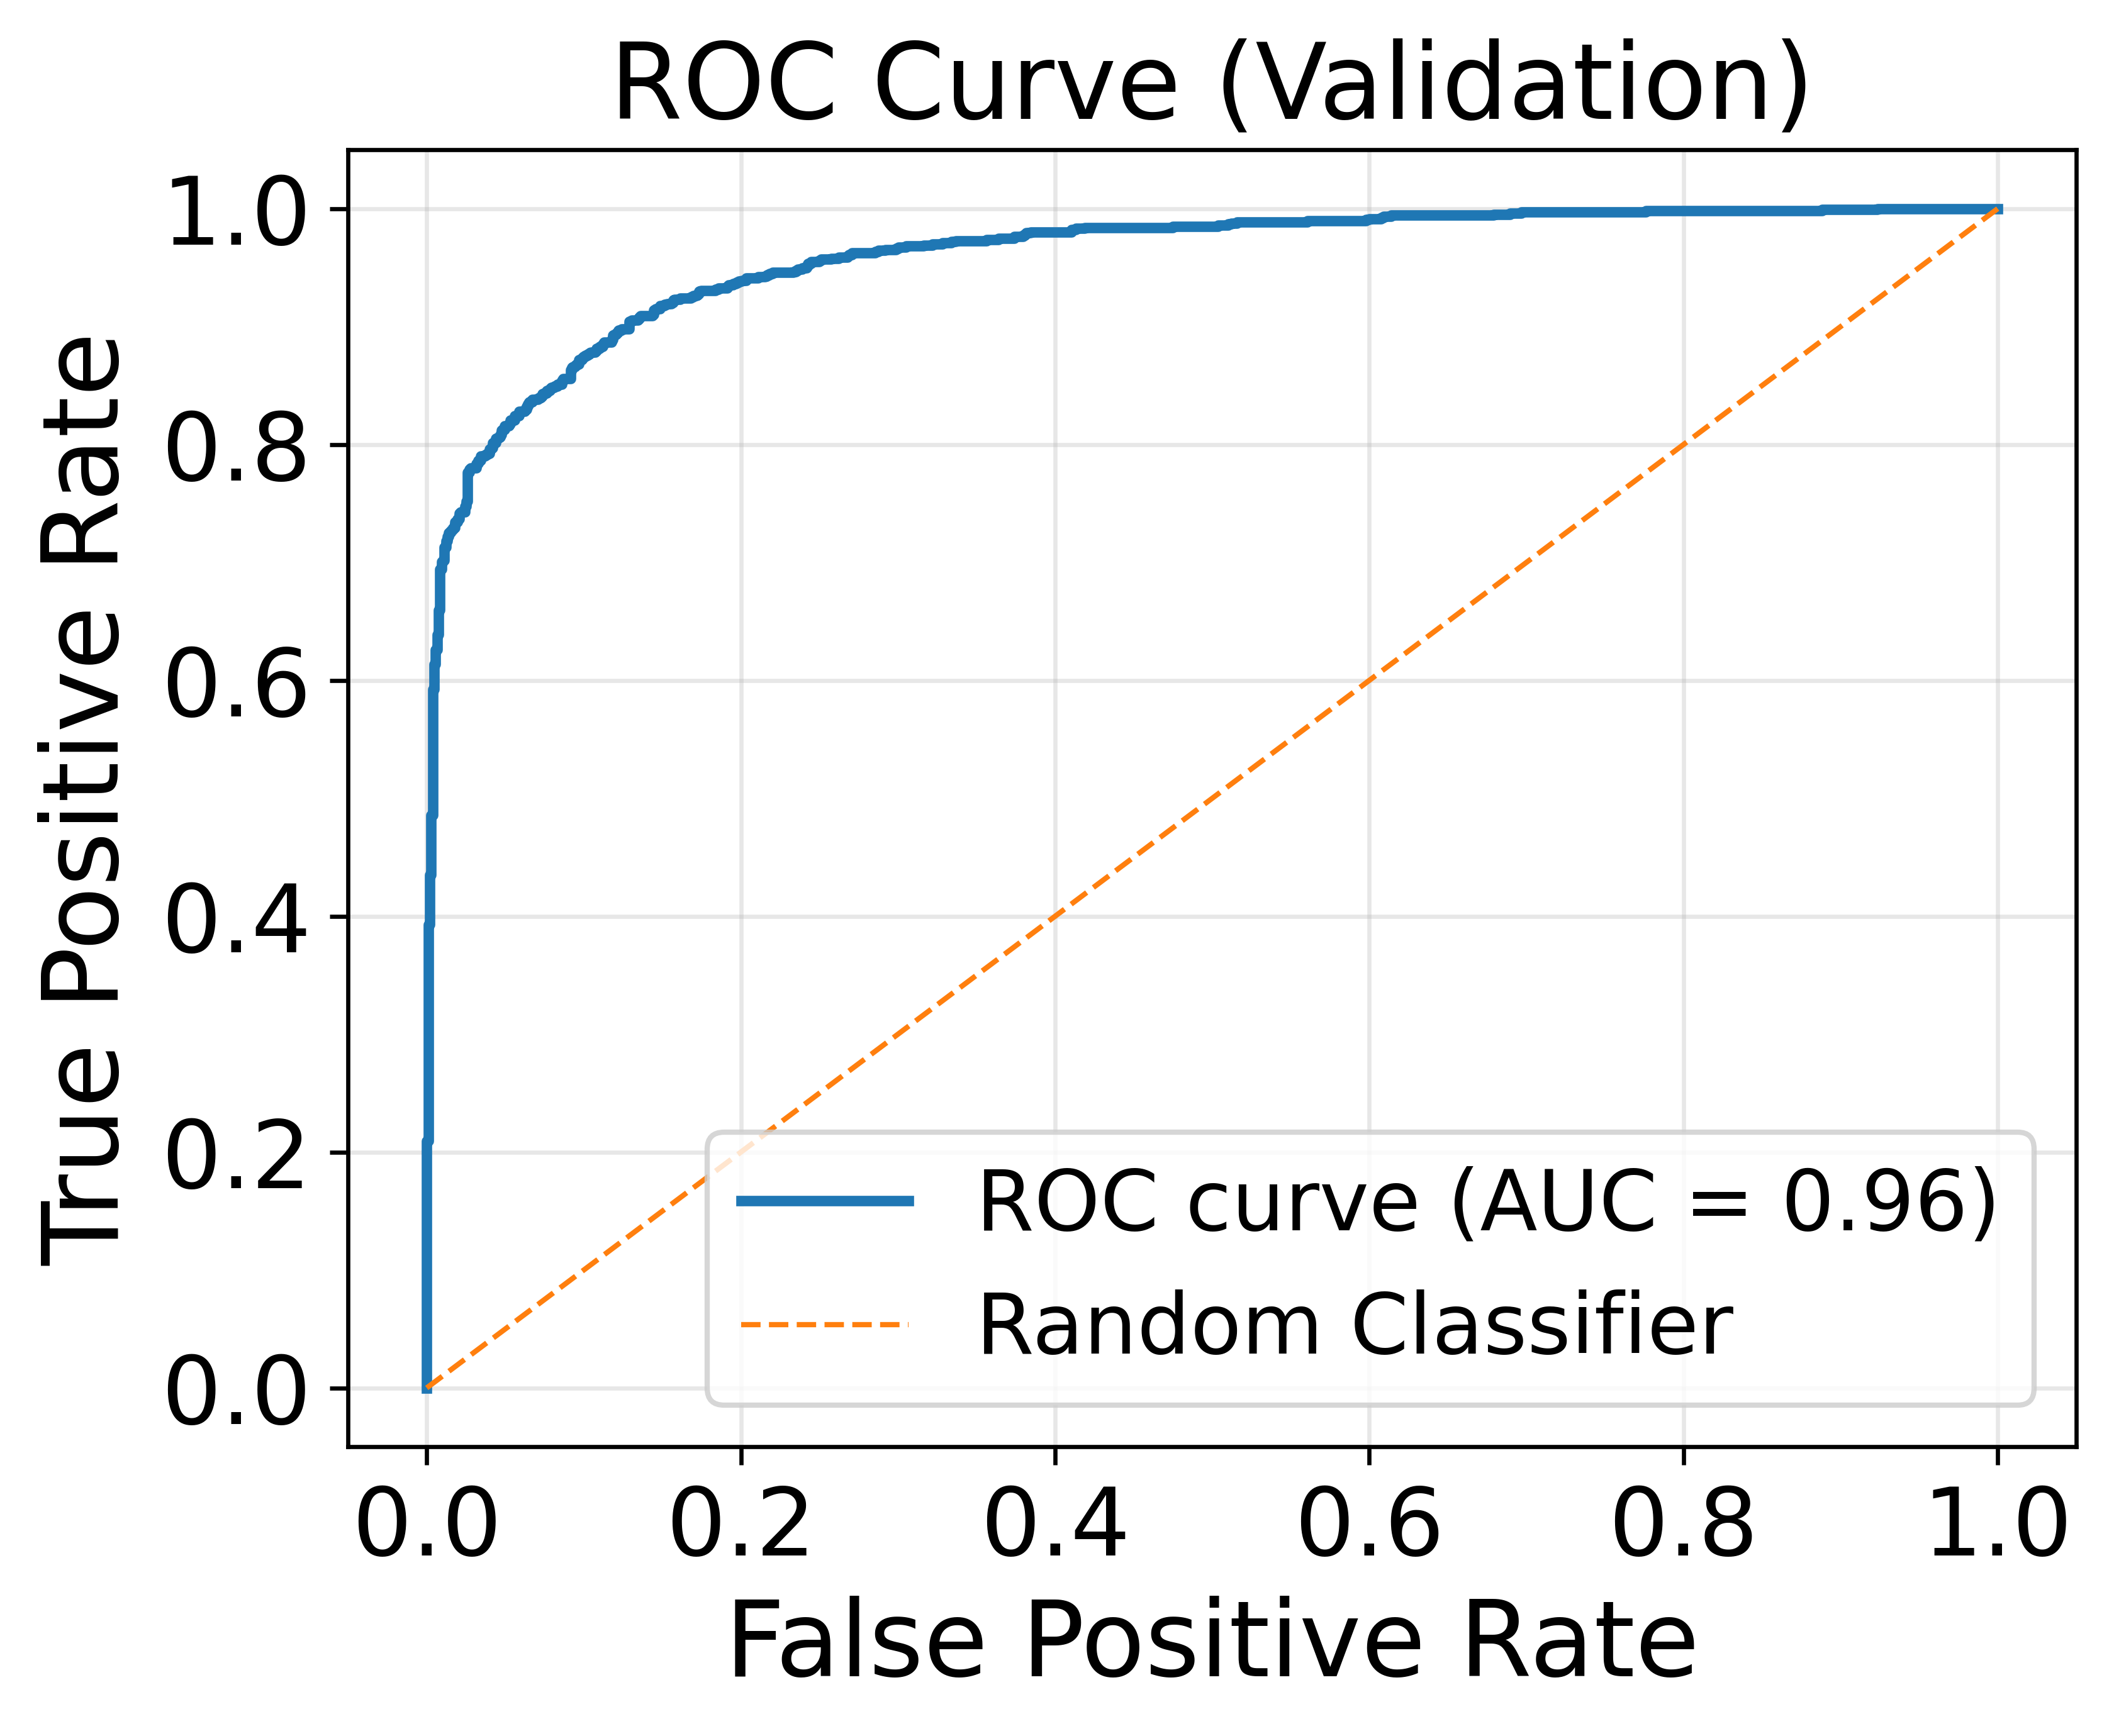


Evaluation Results: Test
Accuracy  : 0.882298
Precision : 0.922441
Recall    : 0.834425
F1-score  : 0.876228
ROC AUC   : 0.955130
----------------------------------------------------------------------
Classification Report:
              precision    recall  f1-score   support

         0.0   0.849233  0.930037  0.887801      1072
         1.0   0.922441  0.834425  0.876228      1069

    accuracy                       0.882298      2141
   macro avg   0.885837  0.882231  0.882014      2141
weighted avg   0.885786  0.882298  0.882022      2141



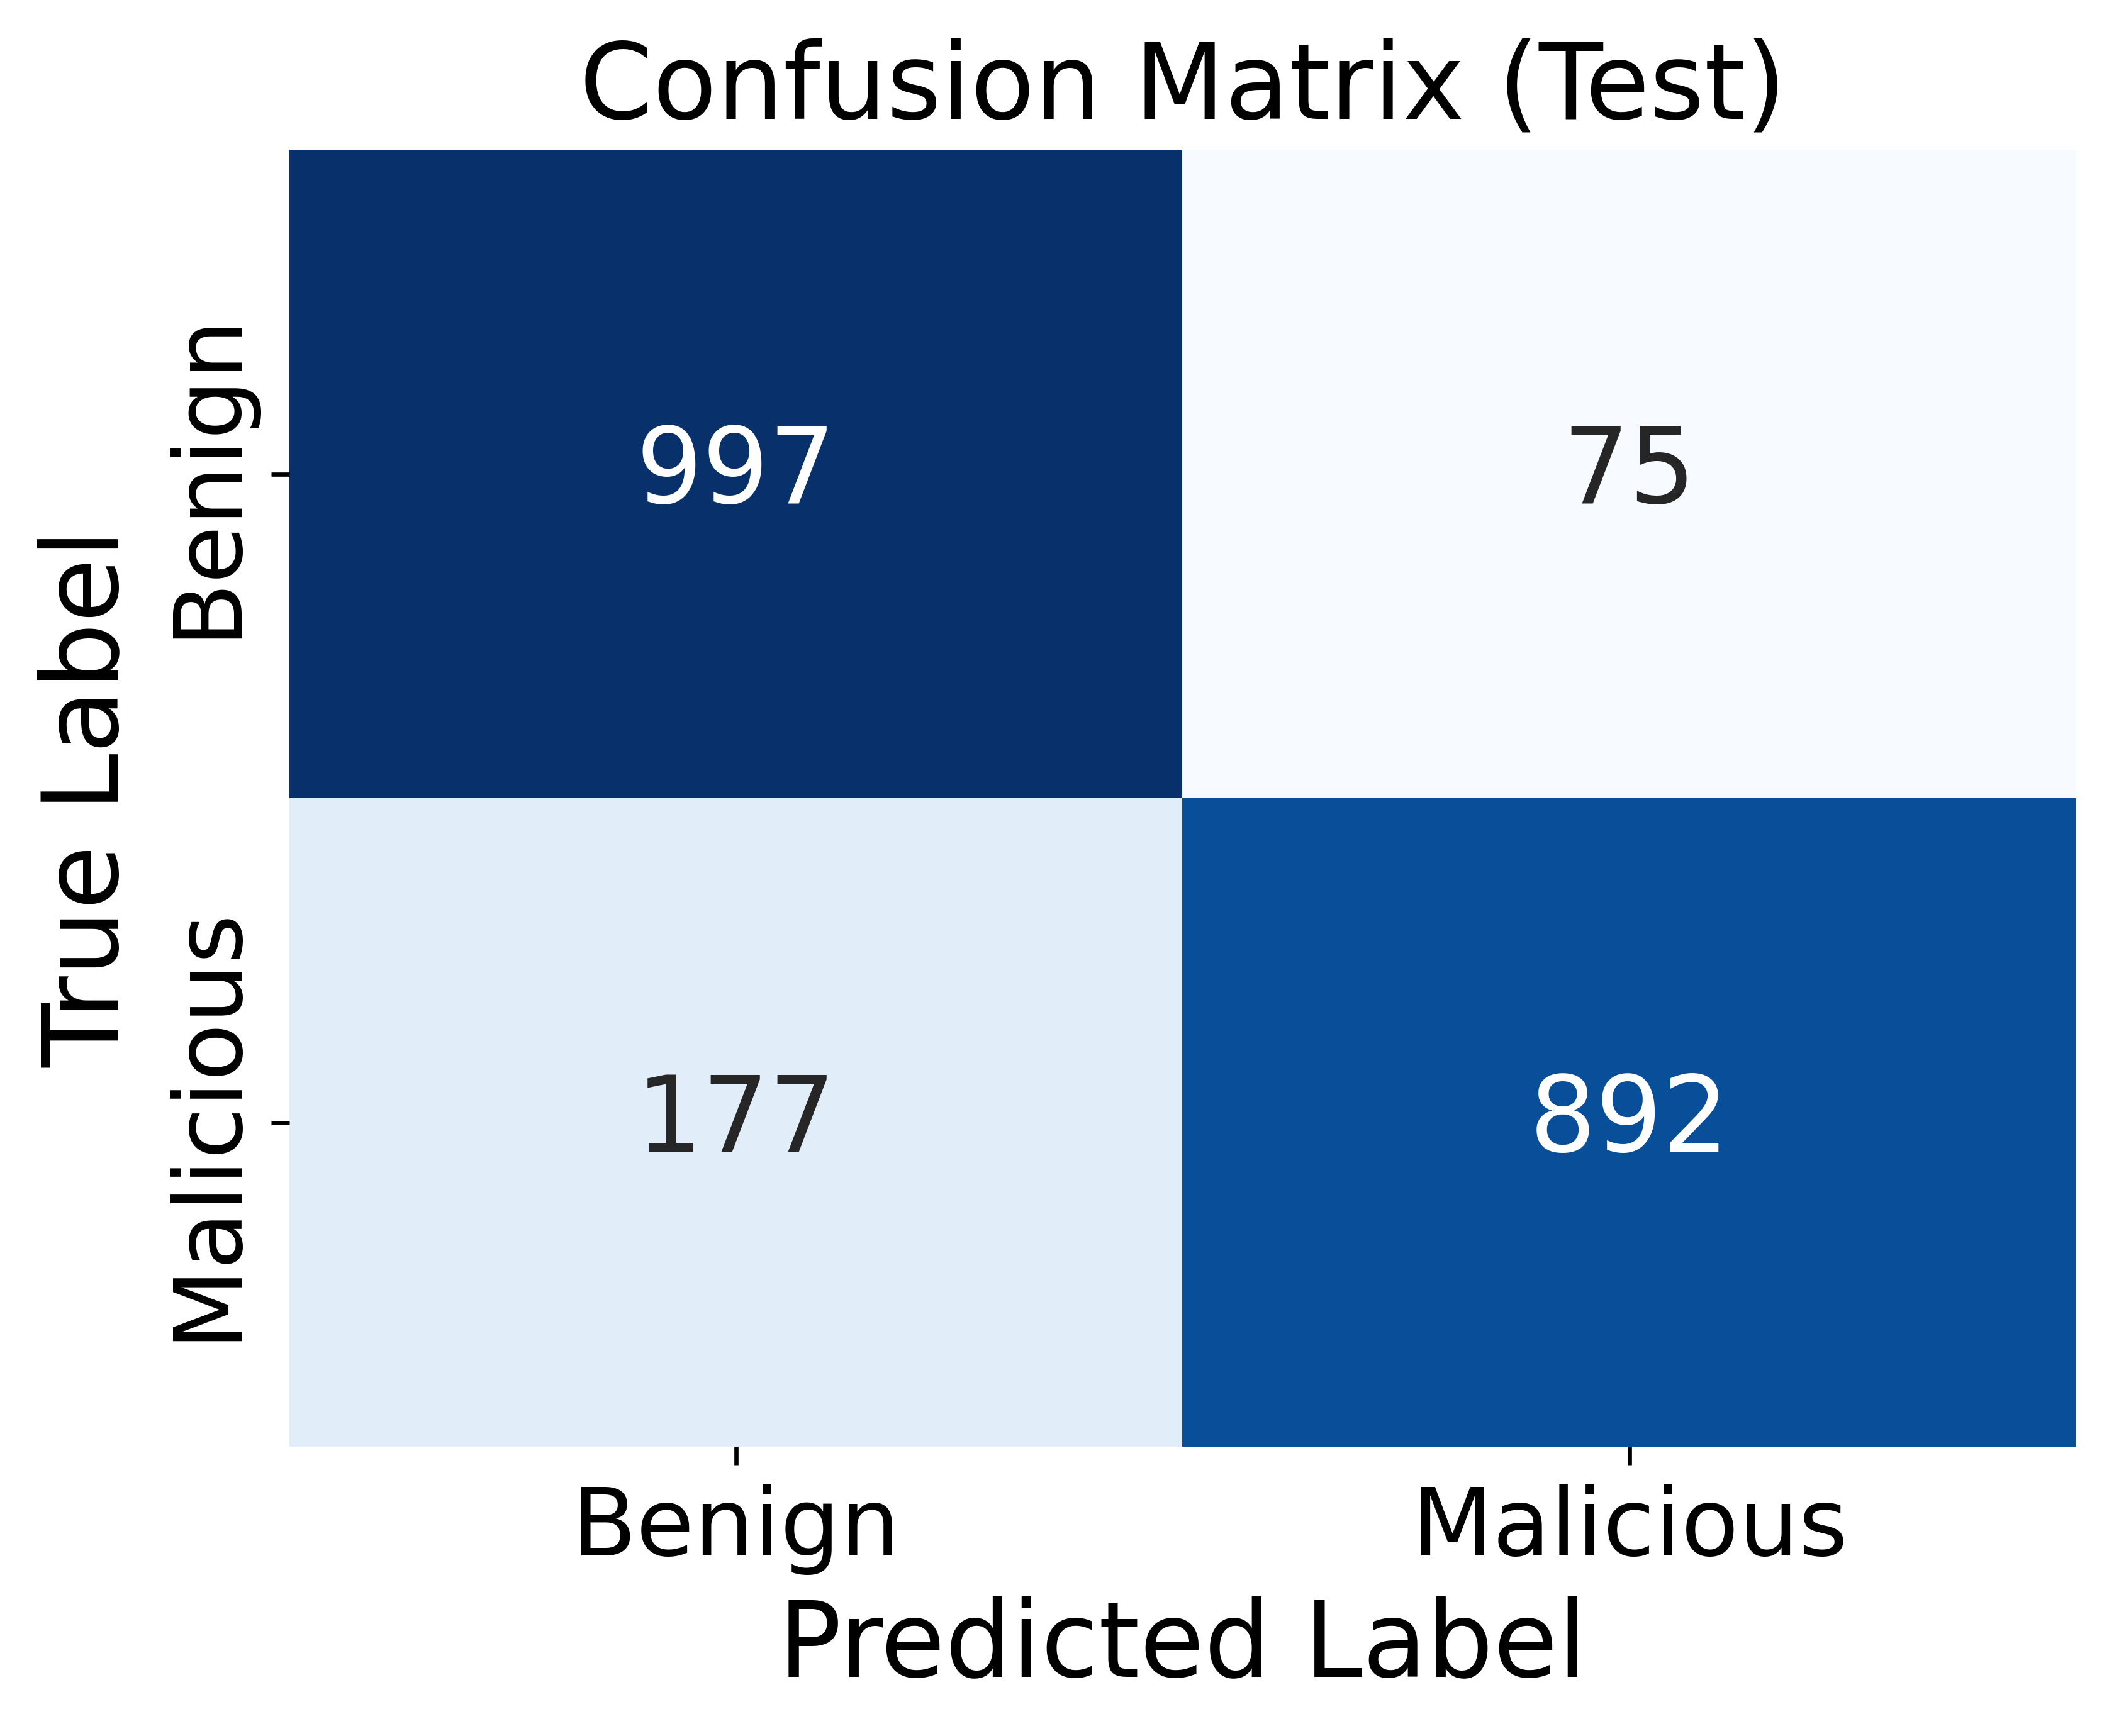

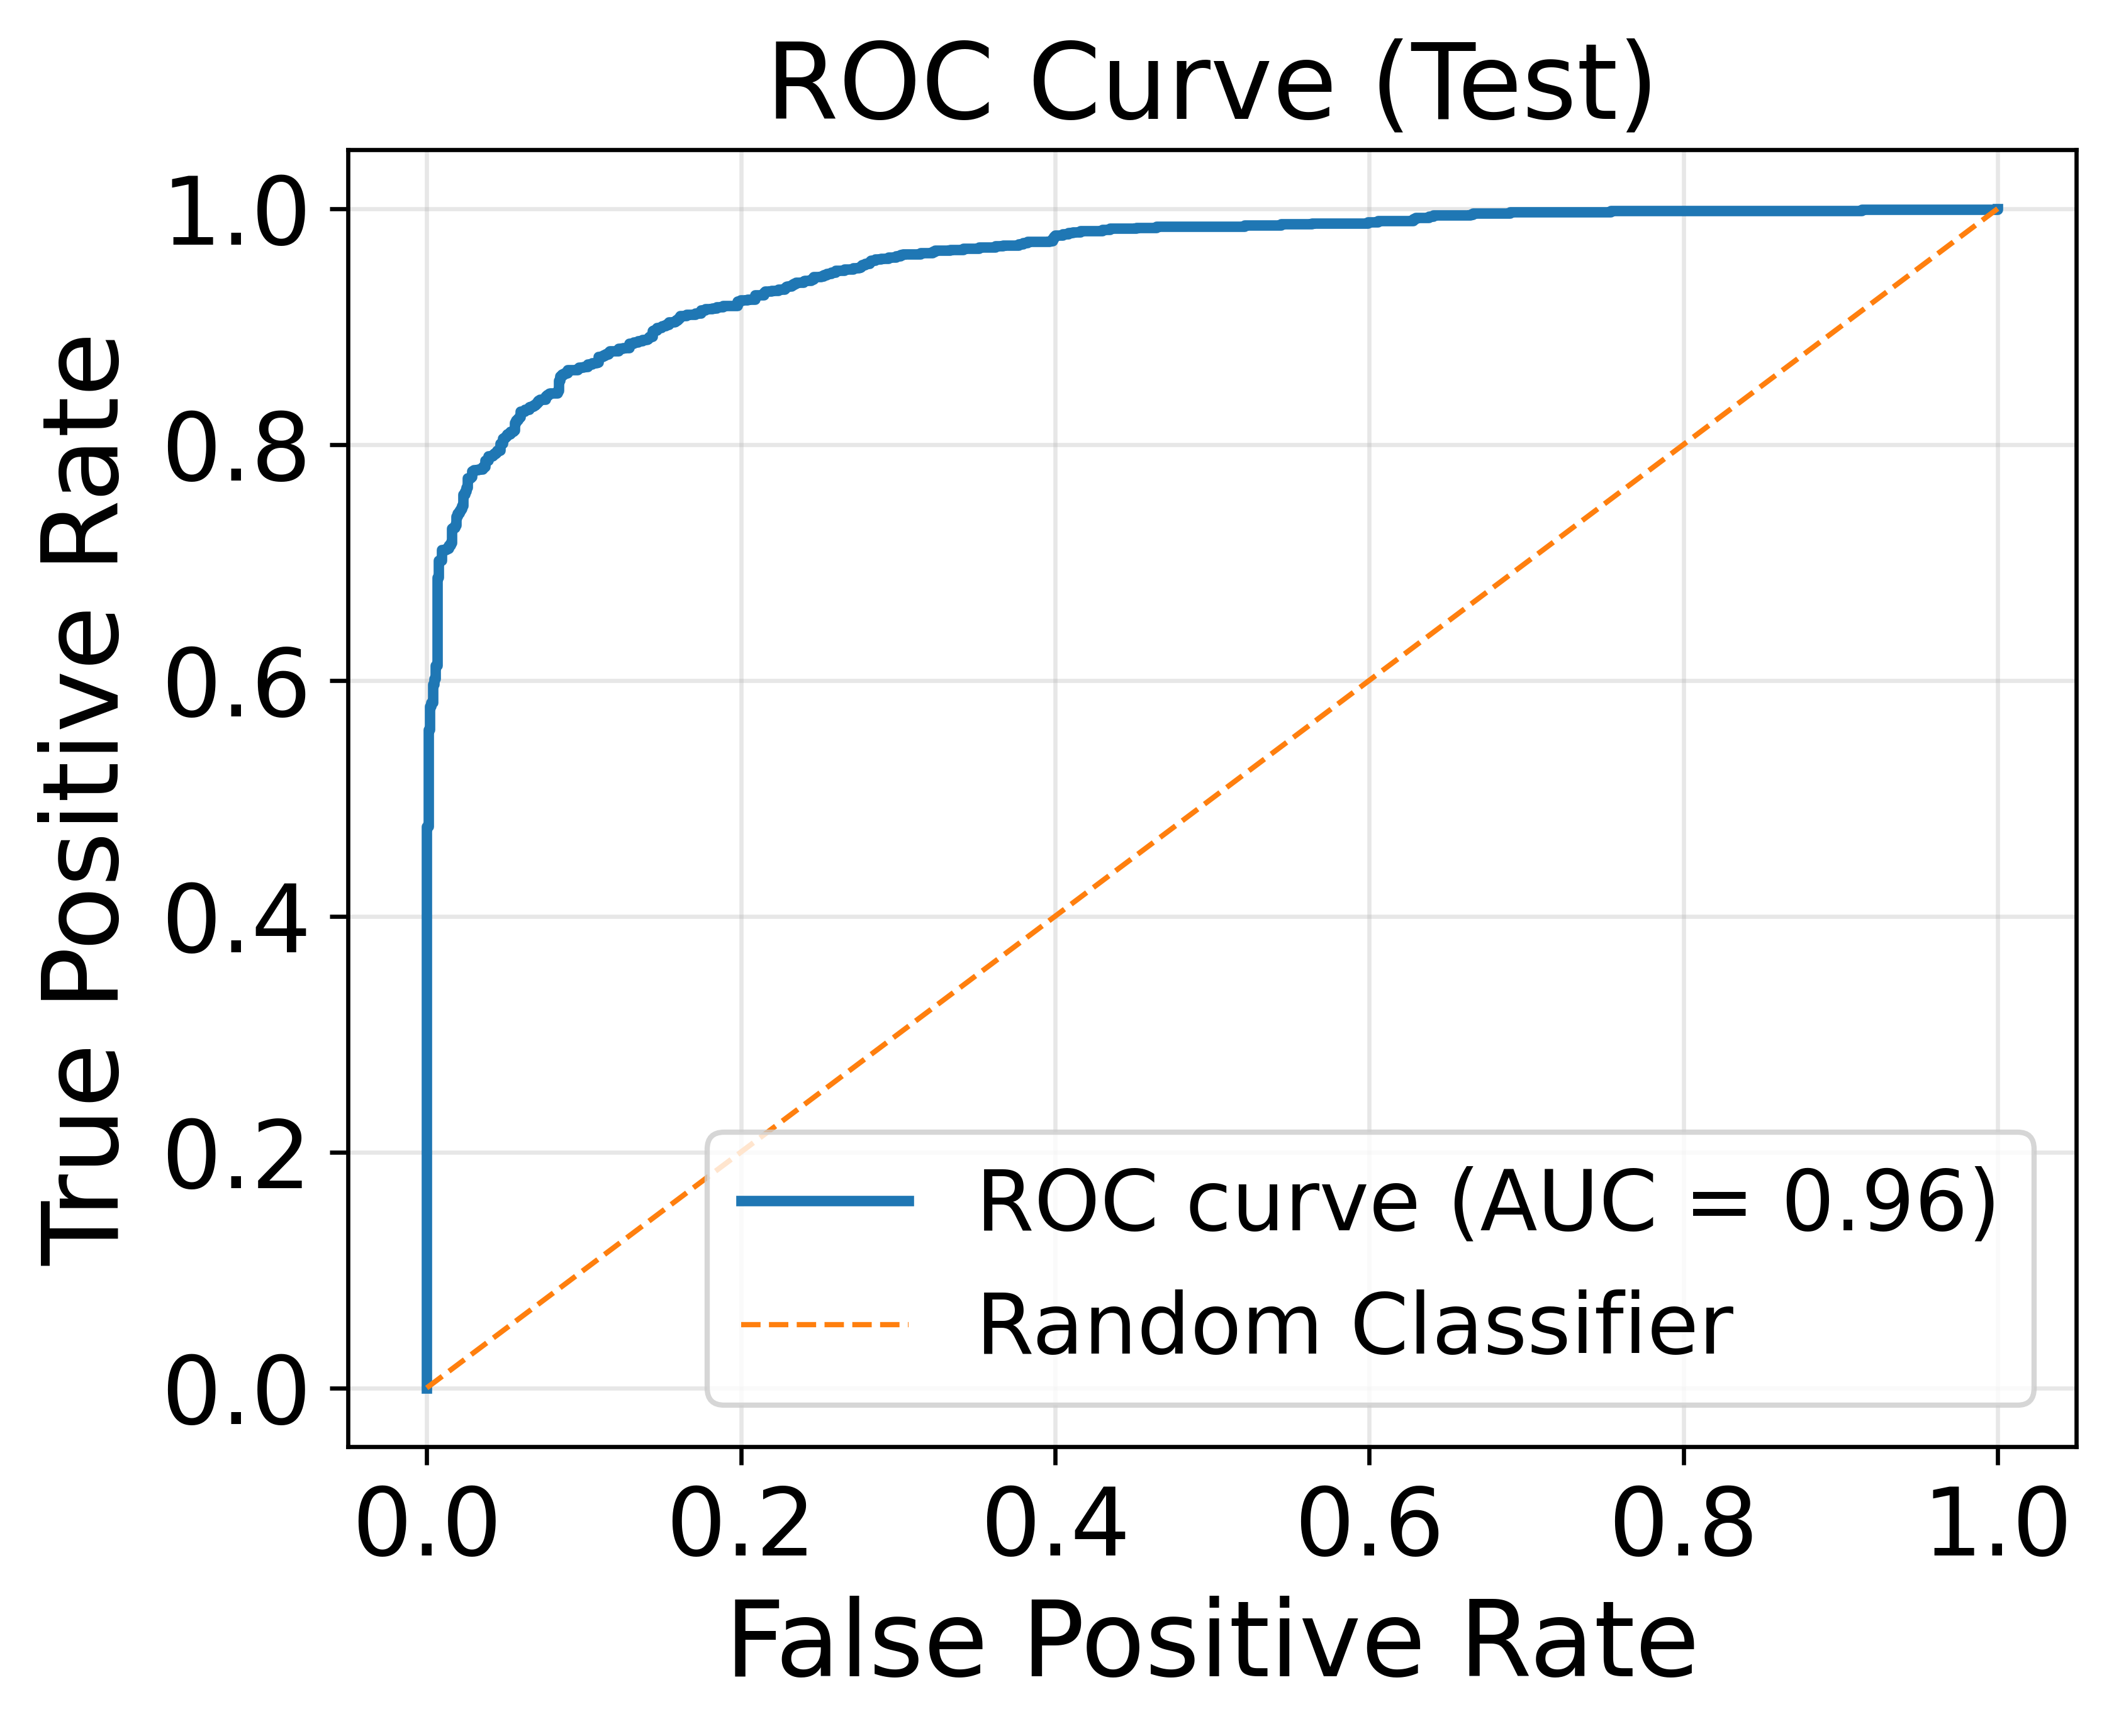

In [19]:
def evaluate_and_plot(model, encodings, X_num, y_true, dataset_name, output_dir=OUTPUT_DIR):
    """
    Evaluate the trained model on a given dataset and generate
    publication-quality confusion matrix and ROC curve figures.

    Parameters
    ----------
    model : keras.Model
        Trained classification model.
    encodings : dict or BatchEncoding
        Tokenized transformer inputs containing 'input_ids' and 'attention_mask'.
    X_num : np.ndarray or sparse matrix
        Additional numerical feature matrix.
    y_true : array-like
        Ground-truth labels.
    dataset_name : str
        Name of the dataset split (e.g., 'Train', 'Validation', 'Test').
    output_dir : str, optional
        Directory where evaluation figures will be saved.

    Returns
    -------
    results : dict
        Dictionary containing predictions and evaluation metrics.
    """

    # --------------------------------------------------------
    # Prepare model inputs
    # --------------------------------------------------------
    inputs = [
        np.array(encodings["input_ids"]),
        np.array(encodings["attention_mask"]),
        X_num
    ]

    # --------------------------------------------------------
    # Generate predictions
    # --------------------------------------------------------
    y_prob = model.predict(inputs, verbose=0).ravel()
    y_pred = (y_prob > 0.5).astype("int32")

    # --------------------------------------------------------
    # Compute evaluation metrics
    # --------------------------------------------------------
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)

    cm = confusion_matrix(y_true, y_pred)
    report = classification_report(y_true, y_pred, digits=6)

    # --------------------------------------------------------
    # Print evaluation summary
    # --------------------------------------------------------
    print("\n" + "=" * 70)
    print(f"Evaluation Results: {dataset_name}")
    print("=" * 70)
    print(f"Accuracy  : {acc:.6f}")
    print(f"Precision : {prec:.6f}")
    print(f"Recall    : {rec:.6f}")
    print(f"F1-score  : {f1:.6f}")
    print(f"ROC AUC   : {roc_auc:.6f}")
    print("-" * 70)
    print("Classification Report:")
    print(report)

    # --------------------------------------------------------
    # Plot and save confusion matrix
    # --------------------------------------------------------
    plt.figure(figsize=(6, 5), dpi=600)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=["Benign", "Malicious"],
        yticklabels=["Benign", "Malicious"]
    )
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"Confusion Matrix ({dataset_name})")
    plt.tight_layout()

    cm_png = os.path.join(output_dir, f"confusion_matrix_{dataset_name.lower()}.png")
    cm_pdf = os.path.join(output_dir, f"confusion_matrix_{dataset_name.lower()}.pdf")
    plt.savefig(cm_png, dpi=600, bbox_inches="tight")
    plt.savefig(cm_pdf, bbox_inches="tight")
    plt.show()

    # --------------------------------------------------------
    # Plot and save ROC curve
    # --------------------------------------------------------
    plt.figure(figsize=(6, 5), dpi=600)
    plt.plot(fpr, tpr, linewidth=2, label=f"ROC curve (AUC = {roc_auc:.2f})")
    plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1, label="Random Classifier")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve ({dataset_name})")
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.tight_layout()

    roc_png = os.path.join(output_dir, f"roc_curve_{dataset_name.lower()}.png")
    roc_pdf = os.path.join(output_dir, f"roc_curve_{dataset_name.lower()}.pdf")
    plt.savefig(roc_png, dpi=600, bbox_inches="tight")
    plt.savefig(roc_pdf, bbox_inches="tight")
    plt.show()

    # --------------------------------------------------------
    # Return results for further analysis/reporting
    # --------------------------------------------------------
    results = {
        "dataset": dataset_name,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1_score": f1,
        "roc_auc": roc_auc,
        "confusion_matrix": cm,
        "classification_report": report,
        "y_true": np.array(y_true),
        "y_pred": y_pred,
        "y_prob": y_prob,
        "confusion_matrix_png": cm_png,
        "confusion_matrix_pdf": cm_pdf,
        "roc_curve_png": roc_png,
        "roc_curve_pdf": roc_pdf
    }

    return results


# ============================================================
# Evaluate on Training, Validation, and Test Sets
# ============================================================

train_results = evaluate_and_plot(model, train_enc, X_train_num, y_train, "Train")
val_results   = evaluate_and_plot(model, val_enc, X_val_num, y_val, "Validation")
test_results  = evaluate_and_plot(model, test_enc, X_test_num, y_test, "Test")

### Save All Results

In [20]:
# ------------------------------------------------------------
# Create summary DataFrame
# ------------------------------------------------------------
summary_df = pd.DataFrame([
    {
        "Dataset": train_results["dataset"],
        "Accuracy": train_results["accuracy"],
        "Precision": train_results["precision"],
        "Recall": train_results["recall"],
        "F1-score": train_results["f1_score"],
        "ROC AUC": train_results["roc_auc"]
    },
    {
        "Dataset": val_results["dataset"],
        "Accuracy": val_results["accuracy"],
        "Precision": val_results["precision"],
        "Recall": val_results["recall"],
        "F1-score": val_results["f1_score"],
        "ROC AUC": val_results["roc_auc"]
    },
    {
        "Dataset": test_results["dataset"],
        "Accuracy": test_results["accuracy"],
        "Precision": test_results["precision"],
        "Recall": test_results["recall"],
        "F1-score": test_results["f1_score"],
        "ROC AUC": test_results["roc_auc"]
    }
])

# ------------------------------------------------------------
# Define save paths
# ------------------------------------------------------------
csv_path  = os.path.join(OUTPUT_DIR, "evaluation_summary.csv")
xlsx_path = os.path.join(OUTPUT_DIR, "evaluation_summary.xlsx")

# ------------------------------------------------------------
# Save files
# ------------------------------------------------------------
summary_df.to_csv(csv_path, index=False)
summary_df.to_excel(xlsx_path, index=False)

# ------------------------------------------------------------
# Confirmation
# ------------------------------------------------------------
print("=" * 60)
print("Evaluation summary saved successfully:")
print(f"CSV  : {csv_path}")
print(f"Excel: {xlsx_path}")
print("=" * 60)

# Display table
summary_df

Evaluation summary saved successfully:
CSV  : Evaluation_Outputs_Opensnoop_WOA_Attention_DistilGPT2\evaluation_summary.csv
Excel: Evaluation_Outputs_Opensnoop_WOA_Attention_DistilGPT2\evaluation_summary.xlsx


,Dataset,Accuracy,Precision,Recall,F1-score,ROC AUC
0,Train,0.900390,0.935456,0.859892,0.896084,0.967598
1,Validation,0.884166,0.915066,0.846586,0.879495,0.958577
2,Test,0.882298,0.922441,0.834425,0.876228,0.955130


### Clear Final Backend Session

In [21]:
# ============================================================
# Memory Management and Session Reset
# ============================================================

# Trigger garbage collection to free unused memory
gc.collect()

# Clear the current TensorFlow/Keras session to release GPU/CPU resources
# This is particularly important when training multiple models sequentially
tf.keras.backend.clear_session()